In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import warnings

import matplotlib.font_manager as fm

try:
    font_path = r'C:\Windows\Fonts\malgun.ttf'
    font_prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = font_prop.get_name()
except:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')

In [44]:

import tensorflow as tf
print("TensorFlow GPU 사용 가능:", len(tf.config.list_physical_devices('GPU')) > 0)
print("GPU 목록:", tf.config.list_physical_devices('GPU'))

try:
    import xgboost as xgb
    print("XGBoost 버전:", xgb.__version__)
except:
    print("XGBoost 미설치")

TensorFlow GPU 사용 가능: False
GPU 목록: []
XGBoost 버전: 3.1.2


In [45]:
df = pd.read_csv('final.csv')
df.drop(['matchId','gameDuration'], axis=1, inplace=True)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
blueWins,94355.0,0.463558,0.498673,0.0,0.0,0.0,1.0,1.0
blueWardsPlaced,94355.0,47.808871,39.392788,9.0,30.0,35.0,48.0,521.0
blueControlWardsPlaced,94355.0,6.943522,2.541030,0.0,5.0,7.0,9.0,25.0
blueWardsDestroyed,94355.0,9.888824,4.043725,0.0,7.0,9.0,12.0,54.0
blueControlWardsDestroyed,94355.0,4.172296,1.889871,0.0,3.0,4.0,5.0,15.0
blueFirstBlood,94355.0,0.494420,0.499972,0.0,0.0,0.0,1.0,1.0
blueKills,94355.0,12.546012,4.840475,0.0,9.0,12.0,16.0,43.0
blueDeaths,94355.0,12.680801,4.813805,0.0,9.0,12.0,16.0,41.0
blueAssists,94355.0,14.778380,6.987882,0.0,10.0,14.0,19.0,55.0
blueDragons,94355.0,0.580202,0.665081,0.0,0.0,0.0,1.0,2.0


In [46]:
print(df.columns.tolist())

['blueWins', 'blueWardsPlaced', 'blueControlWardsPlaced', 'blueWardsDestroyed', 'blueControlWardsDestroyed', 'blueFirstBlood', 'blueKills', 'blueDeaths', 'blueAssists', 'blueDragons', 'blueHeralds', 'blueVoidGrubs', 'blueTowersDestroyed', 'bluePlatesDestroyed', 'blueTotalGold', 'blueTotalExperience', 'blueTotalMinionsKilled', 'blueTotalJungleMinionsKilled', 'blueFirstTurret', 'blueInhibitorsDestroyed', 'blueFirstDragon', 'redWardsPlaced', 'redControlWardsPlaced', 'redWardsDestroyed', 'redControlWardsDestroyed', 'redFirstBlood', 'redKills', 'redDeaths', 'redAssists', 'redDragons', 'redHeralds', 'redVoidGrubs', 'redTowersDestroyed', 'redPlatesDestroyed', 'redTotalGold', 'redTotalExperience', 'redTotalMinionsKilled', 'redTotalJungleMinionsKilled', 'redFirstTurret', 'redInhibitorsDestroyed', 'redFirstDragon']


In [47]:
import pandas as pd
import numpy as np
from scipy import stats

target_vars_ordered = [
    ('성장', 'TotalGold', 'blueTotalGold', 'redTotalGold'),
    ('성장', 'TotalExperience', 'blueTotalExperience', 'redTotalExperience'),
    ('성장', 'TotalMinionsKilled', 'blueTotalMinionsKilled', 'redTotalMinionsKilled'),
    ('성장', 'TotalJungleMinionsKilled', 'blueTotalJungleMinionsKilled', 'redTotalJungleMinionsKilled'),
    ('전투', 'Kills', 'blueKills', 'redKills'),
    ('전투', 'Deaths', 'blueDeaths', 'redDeaths'),
    ('전투', 'Assists', 'blueAssists', 'redAssists'),
    ('전투', 'FirstBlood', 'blueFirstBlood', 'redFirstBlood'),
    ('오브젝트', 'Dragons', 'blueDragons', 'redDragons'),
    ('오브젝트', 'FirstDragon', 'blueFirstDragon', 'redFirstDragon'),
    ('오브젝트', 'Heralds', 'blueHeralds', 'redHeralds'),
    ('오브젝트', 'VoidGrubs', 'blueVoidGrubs', 'redVoidGrubs'),
    ('구조물', 'TowersDestroyed', 'blueTowersDestroyed', 'redTowersDestroyed'),
    ('구조물', 'FirstTowerDestroyed', 'blueFirstTurret', 'redFirstTurret'),
    ('구조물', 'PlatesDestroyed', 'bluePlatesDestroyed', 'redPlatesDestroyed'),
    ('구조물', 'InhibitorsDestroyed', 'blueInhibitorsDestroyed', 'redInhibitorsDestroyed'),
    ('시야', 'WardsPlaced', 'blueWardsPlaced', 'redWardsPlaced'),
    ('시야', 'ControlWardsPlaced', 'blueControlWardsPlaced', 'redControlWardsPlaced'),
    ('시야', 'WardsDestroyed', 'blueWardsDestroyed', 'redWardsDestroyed'),
    ('시야', 'ControlWardsDestroyed', 'blueControlWardsDestroyed', 'redControlWardsDestroyed') 
]

results = []

for category, name, b_col, r_col in target_vars_ordered:
    if b_col in df.columns:
        winner_vals = np.where(df['blueWins'] == 1, df[b_col], df[r_col])
        loser_vals = np.where(df['blueWins'] == 1, df[r_col], df[b_col])
        w_mean = np.mean(winner_vals)
        w_std = np.std(winner_vals)
        w_max = np.max(winner_vals)
        w_min = np.min(winner_vals)
        l_mean = np.mean(loser_vals)
        l_std = np.std(loser_vals)
        l_max = np.max(loser_vals)
        l_min = np.min(loser_vals)
        t_stat, p_val = stats.ttest_ind(winner_vals, loser_vals, equal_var=False)
        p_val_str = "< 0.001" if p_val < 0.001 else f"{p_val:.4f}"

        results.append({
            '구분': category,
            '변수명': name,
            '승리 팀 (평균 ±표편)': f"{w_mean:,.2f} (±{w_std:,.2f})",
            '승리 팀 (최대/최소)': f"{w_max:,.0f} / {w_min:,.0f}",  
            '패배 팀 (평균 ±표편)': f"{l_mean:,.2f} (±{l_std:,.2f})",
            '패배 팀 (최대/최소)': f"{l_max:,.0f} / {l_min:,.0f}",
            'T-value': f"{t_stat:.2f}",
            'P-value': p_val_str
        })

raw_table = pd.DataFrame(results)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("\n=== [1단계: 원본 데이터] 승리 팀 vs 패배 팀 기초 통계 (T-값 포함) ===")
print(raw_table.to_string(index=False))


=== [1단계: 원본 데이터] 승리 팀 vs 패배 팀 기초 통계 (T-값 포함) ===
  구분                      변수명         승리 팀 (평균 ±표편)    승리 팀 (최대/최소)         패배 팀 (평균 ±표편)    패배 팀 (최대/최소) T-value P-value
  성장                TotalGold 29,549.10 (±2,479.02) 42,309 / 21,180 26,945.47 (±2,168.28) 39,022 / 18,519  242.83 < 0.001
  성장          TotalExperience 31,251.07 (±1,641.58) 38,553 / 23,268 29,522.36 (±1,630.14) 38,104 / 20,035  229.53 < 0.001
  성장       TotalMinionsKilled       377.52 (±28.70)       481 / 229       361.04 (±30.71)       483 / 181  120.44 < 0.001
  성장 TotalJungleMinionsKilled        92.41 (±14.23)        172 / 14        86.18 (±13.51)         162 / 0   97.53 < 0.001
  전투                    Kills         14.53 (±4.78)          43 / 0         10.70 (±4.05)          39 / 0  187.46 < 0.001
  전투                   Deaths         10.70 (±4.05)          39 / 0         14.53 (±4.78)          43 / 0 -187.46 < 0.001
  전투                  Assists         17.27 (±7.07)          60 / 0         12.70 (±6.11)      

In [48]:
import pandas as pd

df_clean = df.copy()
start_len = len(df_clean)
print(f"▶ 원본 데이터: {start_len}건")
print("-" * 50)

mask_gold = (df_clean['blueTotalGold'] > 20000) & (df_clean['redTotalGold'] > 20000)
df_clean = df_clean[mask_gold]

print(f"1. [골드] 2만 미만 제거: {start_len - len(df_clean)}건 삭제")
current_len = len(df_clean)

mask_jungle = (df_clean['blueTotalJungleMinionsKilled'] > 0) & (df_clean['redTotalJungleMinionsKilled'] > 0)
df_clean = df_clean[mask_jungle]

print(f"2. [정글] 0마리 제거  : {current_len - len(df_clean)}건 삭제")
current_len = len(df_clean)

mask_ward = (df_clean['blueWardsPlaced'] <= 400) & (df_clean['redWardsPlaced'] <= 400)
df_clean = df_clean[mask_ward]

print(f"3. [와드] 400개 초과 제거: {current_len - len(df_clean)}건 삭제")
print(f"✅ 최종 데이터 수: {len(df_clean)}건")
print(f"   - 총 삭제된 데이터: {start_len - len(df_clean)}건")
print(f"   - 데이터 보존율: {len(df_clean) / start_len * 100:.2f}%")
print(f"(현재 데이터: {len(df_clean)}건)")


▶ 원본 데이터: 94355건
--------------------------------------------------
1. [골드] 2만 미만 제거: 33건 삭제
2. [정글] 0마리 제거  : 2건 삭제
3. [와드] 400개 초과 제거: 140건 삭제
✅ 최종 데이터 수: 94180건
   - 총 삭제된 데이터: 175건
   - 데이터 보존율: 99.81%
(현재 데이터: 94180건)


In [49]:
import pandas as pd
import numpy as np
from scipy import stats

compare_vars_all = [
    ('성장', 'TotalGold', 'blueTotalGold', 'redTotalGold'),
    ('성장', 'TotalExperience', 'blueTotalExperience', 'redTotalExperience'),
    ('성장', 'TotalMinionsKilled', 'blueTotalMinionsKilled', 'redTotalMinionsKilled'),
    ('성장', 'TotalJungleMinionsKilled', 'blueTotalJungleMinionsKilled', 'redTotalJungleMinionsKilled'),
    ('전투', 'Kills', 'blueKills', 'redKills'),
    ('전투', 'Deaths', 'blueDeaths', 'redDeaths'),
    ('전투', 'Assists', 'blueAssists', 'redAssists'),
    ('오브젝트', 'Dragons', 'blueDragons', 'redDragons'),
    ('오브젝트', 'VoidGrubs', 'blueVoidGrubs', 'redVoidGrubs'),
    ('오브젝트', 'Heralds', 'blueHeralds', 'redHeralds'),
    ('구조물', 'TowersDestroyed', 'blueTowersDestroyed', 'redTowersDestroyed'),
    ('구조물', 'PlatesDestroyed', 'bluePlatesDestroyed', 'redPlatesDestroyed'),
    ('구조물', 'InhibitorsDestroyed', 'blueInhibitorsDestroyed', 'redInhibitorsDestroyed'),
    ('시야', 'WardsPlaced', 'blueWardsPlaced', 'redWardsPlaced'),
    ('시야', 'ControlWardsPlaced', 'blueControlWardsPlaced', 'redControlWardsPlaced'),
    ('시야', 'WardsDestroyed', 'blueWardsDestroyed', 'redWardsDestroyed'),
    ('시야', 'ControlWardsDestroyed', 'blueControlWardsDestroyed', 'redControlWardsDestroyed')
]

results = []
win_group_idx = df_clean['blueWins'] == 1
loss_group_idx = df_clean['blueWins'] == 0

print("▶ 전체 변수 대상 Diff vs Ratio 검증 중...")

for category, name, b_col, r_col in compare_vars_all:
    if b_col in df_clean.columns:
        # 1) Diff 변수 생성 & T-test
        diff_data = df_clean[b_col] - df_clean[r_col]
        t_diff, _ = stats.ttest_ind(diff_data[win_group_idx], diff_data[loss_group_idx], equal_var=False)
        
        # 2) Ratio 변수 생성 & T-test
        # 0으로 나누는 것을 방지하기 위해 +1 보정 (Laplace Smoothing)
        if 'Gold' in name or 'Experience' in name:
            # 골드/경험치는 0일 리가 없으므로 그냥 나눔
            ratio_data = df_clean[b_col] / df_clean[r_col]
        else:
            # 킬, 타워 등은 0이 많으므로 +1 보정
            ratio_data = (df_clean[b_col] + 1) / (df_clean[r_col] + 1)
            
        t_ratio, _ = stats.ttest_ind(ratio_data[win_group_idx], ratio_data[loss_group_idx], equal_var=False)
        
        # 3) 승자 판정 (절대값 기준)
        if abs(t_diff) >= abs(t_ratio):
            winner = "Diff (격차)"
            gap = abs(t_diff) - abs(t_ratio)
        else:
            winner = "Ratio (비율)"
            gap = abs(t_ratio) - abs(t_diff)

        results.append({
            '구분': category,
            '변수명': name,
            'Diff T-값': t_diff,
            'Ratio T-값': t_ratio,
            '강한 변수': winner,
            '성능 차이': gap # T-값 차이
        })

comp_df = pd.DataFrame(results)
# 출력pd.set_option('display.max_rows', None)
print("\n=== [최종 검증] Diff(격차) vs Ratio(비율) 설명력 전수 조사 ===")
print(comp_df.to_string(index=False, formatters={'Diff T-값': '{:.2f}'.format, 'Ratio T-값': '{:.2f}'.format, '성능 차이': '{:.2f}'.format}))

▶ 전체 변수 대상 Diff vs Ratio 검증 중...

=== [최종 검증] Diff(격차) vs Ratio(비율) 설명력 전수 조사 ===
  구분                      변수명 Diff T-값 Ratio T-값      강한 변수 성능 차이
  성장                TotalGold   230.02    226.71  Diff (격차)  3.31
  성장          TotalExperience   217.02    214.31  Diff (격차)  2.71
  성장       TotalMinionsKilled   132.88    131.02  Diff (격차)  1.86
  성장 TotalJungleMinionsKilled    89.36     80.62  Diff (격차)  8.74
  전투                    Kills   204.74    165.75  Diff (격차) 38.99
  전투                   Deaths  -204.74   -173.16  Diff (격차) 31.58
  전투                  Assists   160.37    115.21  Diff (격차) 45.16
오브젝트                  Dragons    94.90     89.84  Diff (격차)  5.06
오브젝트                VoidGrubs    66.43     58.82  Diff (격차)  7.62
오브젝트                  Heralds    55.21     51.79  Diff (격차)  3.42
 구조물          TowersDestroyed   130.56    119.79  Diff (격차) 10.77
 구조물          PlatesDestroyed   126.35     98.72  Diff (격차) 27.64
 구조물      InhibitorsDestroyed     7.87      7.03  Diff (격차) 

In [50]:
import pandas as pd

# ======================================================
# 3. 변수 재설계: 격차(Diff) 변수 생성
# ======================================================
# df_clean: 앞서 정제가 완료된 데이터셋 (원본 컬럼 보유)
print("▶ [Step 3] 변수 재설계 (Diff 변수 생성) 시작...")

# 3-1. 수치형 변수 격차 계산 (Blue - Red)
numeric_pairs = [
    # 성장
    ('TotalGold', 'blueTotalGold', 'redTotalGold'),
    ('TotalExperience', 'blueTotalExperience', 'redTotalExperience'),
    ('TotalMinionsKilled', 'blueTotalMinionsKilled', 'redTotalMinionsKilled'),
    ('TotalJungleMinionsKilled', 'blueTotalJungleMinionsKilled', 'redTotalJungleMinionsKilled'),
    # 전투
    ('Kills', 'blueKills', 'redKills'),
    ('Deaths', 'blueDeaths', 'redDeaths'),
    ('Assists', 'blueAssists', 'redAssists'),
    # 시야
    ('WardsPlaced', 'blueWardsPlaced', 'redWardsPlaced'),
    ('ControlWardsPlaced', 'blueControlWardsPlaced', 'redControlWardsPlaced'),
    ('WardsDestroyed', 'blueWardsDestroyed', 'redWardsDestroyed'),
    ('ControlWardsDestroyed', 'blueControlWardsDestroyed', 'redControlWardsDestroyed'),
    # 오브젝트
    ('Dragons', 'blueDragons', 'redDragons'),
    ('Heralds', 'blueHeralds', 'redHeralds'),
    ('VoidGrubs', 'blueVoidGrubs', 'redVoidGrubs'),
    # 구조물
    ('TowersDestroyed', 'blueTowersDestroyed', 'redTowersDestroyed'),
    ('PlatesDestroyed', 'bluePlatesDestroyed', 'redPlatesDestroyed'),
    ('InhibitorsDestroyed', 'blueInhibitorsDestroyed', 'redInhibitorsDestroyed')
]

# 3-2. First 관련 변수 격차 계산 (Blue - Red)
first_pairs = [
    ('FirstTowerDestroyed', 'blueFirstTurret', 'redFirstTurret'),
    ('FirstDragon', 'blueFirstDragon', 'redFirstDragon'),
    ('FirstBlood', 'blueFirstBlood', 'redFirstBlood')
]

# 실제 변수 생성 (df_final에 저장)
df_final = df_clean.copy()
diff_cols = []

# 전체 변수 루프
for name, blue, red in numeric_pairs + first_pairs:
    if blue in df_final.columns and red in df_final.columns:
        col_name = f'Diff_{name}'
        df_final[col_name] = df_final[blue] - df_final[red]
        diff_cols.append(col_name)

# 4. 최종 컬럼 선택 (Diff 변수 + 승패만 남김)
df_final = df_final[diff_cols + ['blueWins']]

print(f"✅ 변수 재설계 완료: {len(df_final.columns)}개 컬럼 (Diff 변수 20개 + 승패 1개)")
print(f"   - 컬럼 목록: {df_final.columns.tolist()}")

▶ [Step 3] 변수 재설계 (Diff 변수 생성) 시작...
✅ 변수 재설계 완료: 21개 컬럼 (Diff 변수 20개 + 승패 1개)
   - 컬럼 목록: ['Diff_TotalGold', 'Diff_TotalExperience', 'Diff_TotalMinionsKilled', 'Diff_TotalJungleMinionsKilled', 'Diff_Kills', 'Diff_Deaths', 'Diff_Assists', 'Diff_WardsPlaced', 'Diff_ControlWardsPlaced', 'Diff_WardsDestroyed', 'Diff_ControlWardsDestroyed', 'Diff_Dragons', 'Diff_Heralds', 'Diff_VoidGrubs', 'Diff_TowersDestroyed', 'Diff_PlatesDestroyed', 'Diff_InhibitorsDestroyed', 'Diff_FirstTowerDestroyed', 'Diff_FirstDragon', 'Diff_FirstBlood', 'blueWins']


In [51]:
import pandas as pd
import numpy as np
from scipy import stats

diff_vars_map = [
    # [성장]
    ('성장', 'TotalGold', 'blueTotalGold', 'redTotalGold'),
    ('성장', 'TotalExperience', 'blueTotalExperience', 'redTotalExperience'),
    ('성장', 'TotalMinionsKilled', 'blueTotalMinionsKilled', 'redTotalMinionsKilled'),
    ('성장', 'TotalJungleMinionsKilled', 'blueTotalJungleMinionsKilled', 'redTotalJungleMinionsKilled'),
    # [전투]
    ('전투', 'Kills', 'blueKills', 'redKills'),
    ('전투', 'Deaths', 'blueDeaths', 'redDeaths'),
    ('전투', 'Assists', 'blueAssists', 'redAssists'),
    ('전투', 'FirstBlood', 'blueFirstBlood', 'redFirstBlood'),
    # [오브젝트]
    ('오브젝트', 'Dragons', 'blueDragons', 'redDragons'),
    ('오브젝트', 'FirstDragon', 'blueFirstDragon', 'redFirstDragon'),
    ('오브젝트', 'VoidGrubs', 'blueVoidGrubs', 'redVoidGrubs'),
    ('오브젝트', 'Heralds', 'blueHeralds', 'redHeralds'),
    # [구조물]
    ('구조물', 'TowersDestroyed', 'blueTowersDestroyed', 'redTowersDestroyed'),
    ('구조물', 'PlatesDestroyed', 'bluePlatesDestroyed', 'redPlatesDestroyed'),
    ('구조물', 'FirstTowerDestroyed', 'blueFirstTurret', 'redFirstTurret'),
    ('구조물', 'InhibitorsDestroyed', 'blueInhibitorsDestroyed', 'redInhibitorsDestroyed'),
    # [시야]
    ('시야', 'ControlWardsPlaced', 'blueControlWardsPlaced', 'redControlWardsPlaced'),
    ('시야', 'WardsDestroyed', 'blueWardsDestroyed', 'redWardsDestroyed'),
    ('시야', 'ControlWardsDestroyed', 'blueControlWardsDestroyed', 'redControlWardsDestroyed'),
    ('시야', 'WardsPlaced', 'blueWardsPlaced', 'redWardsPlaced')
]

results = []
# 승리/패배 그룹 나누기 (df_clean 사용)
win_idx = df_clean['blueWins'] == 1
loss_idx = df_clean['blueWins'] == 0

for category, name, b_col, r_col in diff_vars_map:
    if b_col in df_clean.columns:
        # Diff 데이터 생성 (표 출력을 위해 임시 계산)
        diff_total = df_clean[b_col] - df_clean[r_col]
        
        # 그룹별 데이터
        w_data = diff_total[win_idx]
        l_data = diff_total[loss_idx]
        
        # 통계 계산
        w_mean, w_std = w_data.mean(), w_data.std()
        w_max, w_min = w_data.max(), w_data.min()
        
        l_mean, l_std = l_data.mean(), l_data.std()
        l_max, l_min = l_data.max(), l_data.min()
        
        # T-test
        t_stat, p_val = stats.ttest_ind(w_data, l_data, equal_var=False)
        p_str = "< 0.001" if p_val < 0.001 else f"{p_val:.4f}"

        results.append({
            '구분': category,
            '변수명 (Variable)': f"Diff_{name}", # [수정] 앞에 Diff_ 추가
            
            # 승리 시 격차
            '승리 시 격차 (평균 ±표편)': f"{w_mean:+,.2f} (±{w_std:,.2f})",
            '승리 (최대/최소)': f"{w_max:+,.0f} / {w_min:+,.0f}",
            
            # 패배 시 격차
            '패배 시 격차 (평균 ±표편)': f"{l_mean:+,.2f} (±{l_std:,.2f})",
            '패배 (최대/최소)': f"{l_max:+,.0f} / {l_min:+,.0f}",
            
            'T-value': t_stat,
            'P-value': p_str
        })

# DataFrame 생성
final_df = pd.DataFrame(results)

# 중요도(T-value 절대값) 순 정렬
final_df['abs_t'] = final_df['T-value'].abs()
final_df = final_df.sort_values('abs_t', ascending=False).drop('abs_t', axis=1)

# 출력
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print("\n=== [최종 검증] 정제된 데이터 기반 Diff 변수 분석표 (최대/최소 포함) ===")
print(final_df.to_string(index=False, formatters={'T-value': '{:.2f}'.format}))


=== [최종 검증] 정제된 데이터 기반 Diff 변수 분석표 (최대/최소 포함) ===
  구분                변수명 (Variable)      승리 시 격차 (평균 ±표편)        승리 (최대/최소)      패배 시 격차 (평균 ±표편)        패배 (최대/최소) T-value P-value
  성장                Diff_TotalGold +2,601.13 (±3,460.92) +18,358 / -10,249 -2,599.45 (±3,459.08) +11,375 / -19,575  230.02 < 0.001
  성장          Diff_TotalExperience +1,638.16 (±2,424.60)  +14,569 / -7,734 -1,802.75 (±2,428.59)  +8,188 / -14,067  217.02 < 0.001
  전투                   Diff_Deaths         -3.98 (±5.75)         +20 / -32         +3.69 (±5.71)         +39 / -23 -204.74 < 0.001
  전투                    Diff_Kills         +3.98 (±5.75)         +32 / -20         -3.69 (±5.71)         +23 / -39  204.74 < 0.001
  전투                  Diff_Assists         +4.47 (±8.77)         +41 / -33         -4.65 (±8.63)         +36 / -46  160.37 < 0.001
  성장       Diff_TotalMinionsKilled       +13.00 (±37.48)       +183 / -169       -19.43 (±37.20)       +133 / -199  132.88 < 0.001
 구조물          Diff_TowersDestroy

▶ 분석 대상 변수: 20개


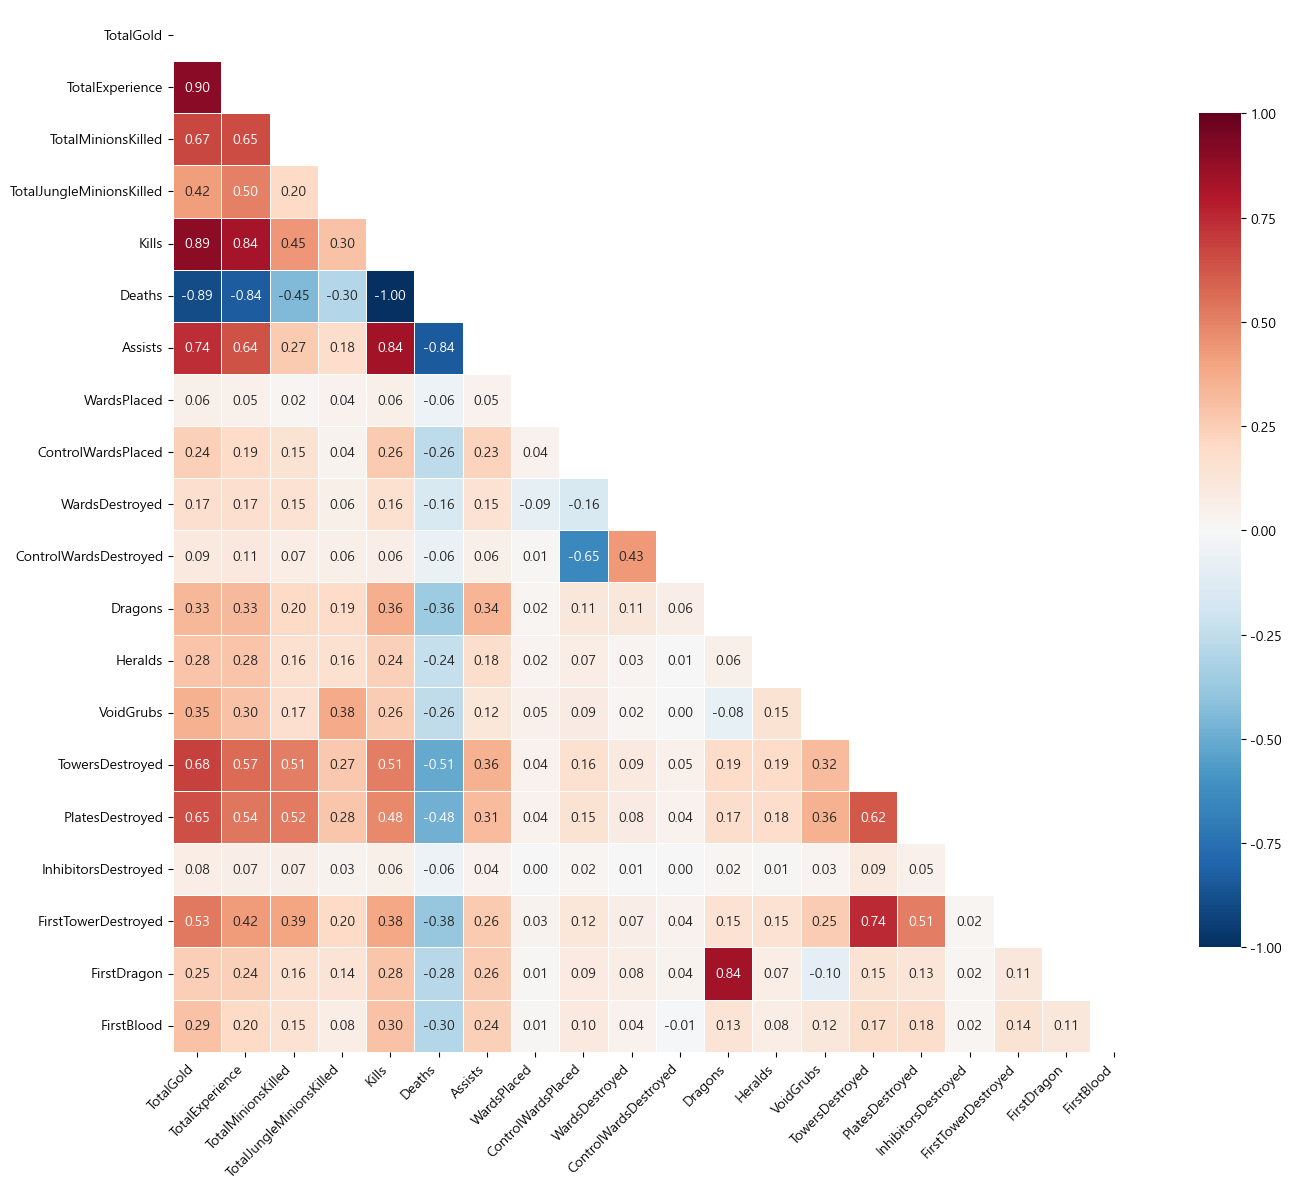

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

valid_cols = [col for col in df_final.columns if col.startswith('Diff_')]

X_data = df_final[valid_cols].copy()
print(f"▶ 분석 대상 변수: {len(valid_cols)}개")

# ======================================================
# 2. 데이터 스케일링 (StandardScaler)
# ======================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_data)

# 스케일링된 데이터를 다시 DataFrame으로 변환 (히트맵 그리기 위해)
X_scaled_df = pd.DataFrame(X_scaled, columns=valid_cols)

# ======================================================
# 3. 상관계수 히트맵 시각화
# ======================================================
plt.figure(figsize=(14, 12))

# 상관계수 계산 (스케일링된 데이터 사용)
corr_matrix = X_scaled_df.corr()

# 마스킹 (대각선 위쪽 가리기)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r', 
            mask=mask, 
            vmax=1, vmin=-1, center=0, 
            linewidths=.5, cbar_kws={"shrink": .8})

# 축 이름 깔끔하게 정리
clean_labels = [c.replace('Diff_', '') for c in valid_cols] 

plt.xticks(np.arange(len(clean_labels)) + 0.5, clean_labels, rotation=45, ha='right', fontsize=10)
plt.yticks(np.arange(len(clean_labels)) + 0.5, clean_labels, rotation=0, fontsize=10)

plt.tight_layout()
plt.show()


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA


# 변수명 깔끔하게 정리 (Diff_ 제거)
feature_names = [col.replace('Diff_', '') for col in diff_cols]

print(f"▶ PCA 분석 시작 (목표 설명력: 95%)")
print(f"   - 원본 변수 개수: {X_scaled.shape[1]}개")

pca = PCA(n_components=0.95) 
X_pca = pca.fit_transform(X_scaled)

# 결과 확인
n_components = pca.n_components_
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"✅ 분석 완료: {n_components}개의 주성분으로 전체 정보의 {cumulative_variance[-1]*100:.2f}% 설명 가능")
print("-" * 60)

loadings = pd.DataFrame(
    pca.components_, 
    columns=feature_names,
    index=[f'PC{i+1}' for i in range(n_components)]
)

pc_interpretation = []

for i in range(n_components):
    pc_name = f'PC{i+1}'
    
    # 해당 PC에 영향력이 큰 변수 Top 3 추출 (절대값 기준)
    sorted_loadings = loadings.loc[pc_name].abs().sort_values(ascending=False)
    top_vars = sorted_loadings.index[:3].tolist()
    
    # 부호 확인 (+: 양의 상관, -: 음의 상관)
    details = []
    for var in top_vars:
        value = loadings.loc[pc_name, var]
        sign = "(+)" if value > 0 else "(-)"
        details.append(f"{var}{sign}")
    
    # 정보 저장
    pc_interpretation.append({
        '주성분': pc_name,
        '설명력(%)': f"{explained_variance[i]*100:.1f}%",
        '누적(%)': f"{cumulative_variance[i]*100:.1f}%",
        '핵심 구성 변수 (Top 3)': ", ".join(details)
    })

# 결과 데이터프레임 생성
interpretation_df = pd.DataFrame(pc_interpretation)

# 표 출력
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
print("\n=== [PCA 결과 해석] 주성분별 구성 요소 분석표 ===")
print(interpretation_df.to_string(index=False))

▶ PCA 분석 시작 (목표 설명력: 95%)
   - 원본 변수 개수: 20개
✅ 분석 완료: 13개의 주성분으로 전체 정보의 95.16% 설명 가능
------------------------------------------------------------

=== [PCA 결과 해석] 주성분별 구성 요소 분석표 ===
 주성분 설명력(%) 누적(%)                                                    핵심 구성 변수 (Top 3)
 PC1  33.4% 33.4%                                   TotalGold(+), Kills(+), Deaths(-)
 PC2   9.4% 42.8%  ControlWardsDestroyed(+), ControlWardsPlaced(-), WardsDestroyed(+)
 PC3   9.2% 52.0%                   FirstDragon(+), Dragons(+), ControlWardsPlaced(+)
 PC4   6.4% 58.4%                  Assists(+), FirstDragon(-), FirstTowerDestroyed(-)
 PC5   5.5% 63.9%           TotalJungleMinionsKilled(+), VoidGrubs(+), WardsPlaced(+)
 PC6   5.0% 68.9% WardsPlaced(+), InhibitorsDestroyed(+), TotalJungleMinionsKilled(-)
 PC7   5.0% 73.9% InhibitorsDestroyed(+), WardsPlaced(-), TotalJungleMinionsKilled(+)
 PC8   4.6% 78.5%                             FirstBlood(+), Heralds(-), VoidGrubs(+)
 PC9   4.4% 83.0%              Heralds(+), F

In [54]:
print("\n=== [PCA 주성분 수식 (가중치 내림차순 정렬)] ===")

for i in range(n_components):
    pc_name = f'PC{i+1}'
    
    # 1. 해당 PC의 가중치(Loading)를 가져와서 절대값 기준 내림차순 정렬
    # (부호는 살려두기 위해 인덱스만 뽑아서 재정렬합니다)
    sorted_indices = loadings.loc[pc_name].abs().sort_values(ascending=False).index
    sorted_row = loadings.loc[pc_name, sorted_indices]
    
    # 2. 수식 문자열 생성
    equation_parts = []
    for var, coeff in sorted_row.items():
        # 가독성을 위해 계수가 0.05 미만인 너무 작은 항목은 제외하고 싶다면 아래 주석 해제
        # if abs(coeff) < 0.05: continue 
        
        # {coeff:+.3f} : 부호(+/-)를 강제로 표시하고 소수점 3자리까지 출력
        equation_parts.append(f"({coeff:+.3f} * {var})")
    
    # 3. 전체 수식 결합
    full_equation = " ".join(equation_parts) # 괄호 사이에 공백 추가
    
    print(f"[{pc_name} 설명력: {explained_variance[i]*100:.1f}%]")
    print(f"{pc_name} = {full_equation}")
    print("-" * 80)


=== [PCA 주성분 수식 (가중치 내림차순 정렬)] ===
[PC1 설명력: 33.4%]
PC1 = (+0.375 * TotalGold) (+0.349 * Kills) (-0.349 * Deaths) (+0.349 * TotalExperience) (+0.287 * Assists) (+0.281 * TowersDestroyed) (+0.263 * PlatesDestroyed) (+0.250 * TotalMinionsKilled) (+0.229 * FirstTowerDestroyed) (+0.173 * TotalJungleMinionsKilled) (+0.169 * Dragons) (+0.144 * VoidGrubs) (+0.137 * FirstDragon) (+0.126 * FirstBlood) (+0.121 * Heralds) (+0.105 * ControlWardsPlaced) (+0.075 * WardsDestroyed) (+0.034 * InhibitorsDestroyed) (+0.032 * ControlWardsDestroyed) (+0.026 * WardsPlaced)
--------------------------------------------------------------------------------
[PC2 설명력: 9.4%]
PC2 = (+0.559 * ControlWardsDestroyed) (-0.462 * ControlWardsPlaced) (+0.408 * WardsDestroyed) (+0.320 * Dragons) (+0.314 * FirstDragon) (-0.219 * VoidGrubs) (-0.119 * FirstTowerDestroyed) (-0.118 * PlatesDestroyed) (-0.115 * TowersDestroyed) (+0.077 * Assists) (-0.065 * WardsPlaced) (-0.055 * Heralds) (-0.031 * Deaths) (+0.031 * Kills) (-0.0

In [ ]:

# 1. df_final (전처리 완료 데이터)
#    - 생성 위치: Cell 8
#    - 내용: Diff 변수 20개 + blueWins (승패)
#    - 특징: Blue - Red 격차 변수로 재설계 완료

# 2. X_scaled (스케일링 적용 데이터)
#    - 생성 위치: Cell 10
#    - 내용: StandardScaler로 정규화된 Diff 변수
#    - 특징: 평균 0, 표준편차 1로 변환

# 3. X_pca (PCA 차원축소 데이터)
#    - 생성 위치: Cell 11
#    - 내용: PCA(n_components=0.95) 적용
#    - 특징: 95% 설명력 유지하며 차원 축소


In [ ]:

from sklearn.model_selection import train_test_split

# 타겟 변수 분리
y = df_final['blueWins']

# 1) Original 데이터 (df_final)
X_original = df_final.drop('blueWins', axis=1)

# 2) Scaled 데이터 (X_scaled) - numpy array를 DataFrame으로 변환
X_scaled_df = pd.DataFrame(X_scaled, columns=X_original.columns)

# 3) PCA 데이터 (X_pca) - numpy array를 DataFrame으로 변환
X_pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])

# 데이터 분할 (80:20, stratify=y, random_state=42)
X_train_orig, X_test_orig, y_train, y_test = train_test_split(
    X_original, y, test_size=0.2, stratify=y, random_state=42
)

X_train_scaled, X_test_scaled, _, _ = train_test_split(
    X_scaled_df, y, test_size=0.2, stratify=y, random_state=42
)

X_train_pca, X_test_pca, _, _ = train_test_split(
    X_pca_df, y, test_size=0.2, stratify=y, random_state=42
)

# 결과 확인
print("=" * 60)
print("데이터 분할 완료 (Train 80% : Test 20%)")
print("=" * 60)
print(f"Original  - Train: {X_train_orig.shape}, Test: {X_test_orig.shape}")
print(f"Scaled    - Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")
print(f"PCA       - Train: {X_train_pca.shape}, Test: {X_test_pca.shape}")
print(f"\n승패 비율 (Train): {y_train.value_counts(normalize=True).to_dict()}")
print(f"승패 비율 (Test):  {y_test.value_counts(normalize=True).to_dict()}")

데이터 분할 완료 (Train 80% : Test 20%)
Original  - Train: (75344, 20), Test: (18836, 20)
Scaled    - Train: (75344, 20), Test: (18836, 20)
PCA       - Train: (75344, 13), Test: (18836, 13)

승패 비율 (Train): {0: 0.5364196220004247, 1: 0.4635803779995753}
승패 비율 (Test):  {0: 0.5364196220004247, 1: 0.4635803779995753}


In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

print("=" * 60)
print("[1/7] Logistic Regression 학습 중...")
print("=" * 60)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

models_lr = {}
lr_params = {'max_iter': 1000, 'random_state': 42}

# 1) Original
lr_orig = LogisticRegression(**lr_params)
lr_orig.fit(X_train_orig, y_train)
models_lr['Original'] = lr_orig
y_pred = lr_orig.predict(X_test_orig)
print(f"\nOriginal:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred):.4f}")

# 2) Scaled
lr_scaled = LogisticRegression(**lr_params)
lr_scaled.fit(X_train_scaled, y_train)
models_lr['Scaled'] = lr_scaled
y_pred = lr_scaled.predict(X_test_scaled)
print(f"\nScaled:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred):.4f}")

# 3) PCA
lr_pca = LogisticRegression(**lr_params)
lr_pca.fit(X_train_pca, y_train)
models_lr['PCA'] = lr_pca
y_pred = lr_pca.predict(X_test_pca)
print(f"\nPCA:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred):.4f}")

print(f"\n하이퍼파라미터: {lr_params}")
print("\n✅ Logistic Regression 학습 완료")

[1/7] Logistic Regression 학습 중...

Original:
  Accuracy:  0.7872
  Precision: 0.7754
  Recall:    0.7616
  F1-Score:  0.7684

Scaled:
  Accuracy:  0.7880
  Precision: 0.7769
  Recall:    0.7612
  F1-Score:  0.7690

PCA:
  Accuracy:  0.7862
  Precision: 0.7753
  Recall:    0.7587
  F1-Score:  0.7669

하이퍼파라미터: {'max_iter': 1000, 'random_state': 42}

✅ Logistic Regression 학습 완료


In [ ]:

from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import GridSearchCV

print("=" * 60)
print("[2/7] Ridge Classifier 학습 중 (GridSearchCV)...")
print("=" * 60)

param_grid_ridge = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

models_ridge = {}

# 1) Original
ridge_orig = GridSearchCV(RidgeClassifier(random_state=42), param_grid_ridge, cv=cv, scoring='f1', n_jobs=-1)
ridge_orig.fit(X_train_orig, y_train)
models_ridge['Original'] = ridge_orig.best_estimator_
y_pred = ridge_orig.predict(X_test_orig)
print(f"\nOriginal - Best alpha: {ridge_orig.best_params_['alpha']}")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred):.4f}")

# 2) Scaled
ridge_scaled = GridSearchCV(RidgeClassifier(random_state=42), param_grid_ridge, cv=cv, scoring='f1', n_jobs=-1)
ridge_scaled.fit(X_train_scaled, y_train)
models_ridge['Scaled'] = ridge_scaled.best_estimator_
y_pred = ridge_scaled.predict(X_test_scaled)
print(f"\nScaled - Best alpha: {ridge_scaled.best_params_['alpha']}")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred):.4f}")

# 3) PCA
ridge_pca = GridSearchCV(RidgeClassifier(random_state=42), param_grid_ridge, cv=cv, scoring='f1', n_jobs=-1)
ridge_pca.fit(X_train_pca, y_train)
models_ridge['PCA'] = ridge_pca.best_estimator_
y_pred = ridge_pca.predict(X_test_pca)
print(f"\nPCA - Best alpha: {ridge_pca.best_params_['alpha']}")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred):.4f}")

print(f"\n하이퍼파라미터 범위: alpha={param_grid_ridge['alpha']}")
print("\n✅ Ridge Classifier 학습 완료")

[2/7] Ridge Classifier 학습 중 (GridSearchCV)...

Original - Best alpha: 100
  Accuracy:  0.7864
  Precision: 0.7758
  Recall:    0.7584
  F1-Score:  0.7670

Scaled - Best alpha: 10
  Accuracy:  0.7862
  Precision: 0.7754
  Recall:    0.7585
  F1-Score:  0.7669

PCA - Best alpha: 100
  Accuracy:  0.7861
  Precision: 0.7765
  Recall:    0.7562
  F1-Score:  0.7662

하이퍼파라미터 범위: alpha=[0.001, 0.01, 0.1, 1, 10, 100]

✅ Ridge Classifier 학습 완료


In [ ]:

from sklearn.linear_model import LogisticRegression

print("=" * 60)
print("[3/7] Lasso (L1 Regularization) 학습 중 (GridSearchCV)...")
print("=" * 60)

param_grid_lasso = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

models_lasso = {}

# 1) Original
lasso_orig = GridSearchCV(
    LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=42),
    param_grid_lasso, cv=cv, scoring='f1', n_jobs=-1
)
lasso_orig.fit(X_train_orig, y_train)
models_lasso['Original'] = lasso_orig.best_estimator_
y_pred = lasso_orig.predict(X_test_orig)
print(f"\nOriginal - Best C: {lasso_orig.best_params_['C']}")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred):.4f}")

# 2) Scaled
lasso_scaled = GridSearchCV(
    LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=42),
    param_grid_lasso, cv=cv, scoring='f1', n_jobs=-1
)
lasso_scaled.fit(X_train_scaled, y_train)
models_lasso['Scaled'] = lasso_scaled.best_estimator_
y_pred = lasso_scaled.predict(X_test_scaled)
print(f"\nScaled - Best C: {lasso_scaled.best_params_['C']}")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred):.4f}")

# 3) PCA
lasso_pca = GridSearchCV(
    LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=42),
    param_grid_lasso, cv=cv, scoring='f1', n_jobs=-1
)
lasso_pca.fit(X_train_pca, y_train)
models_lasso['PCA'] = lasso_pca.best_estimator_
y_pred = lasso_pca.predict(X_test_pca)
print(f"\nPCA - Best C: {lasso_pca.best_params_['C']}")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred):.4f}")

print(f"\n하이퍼파라미터 범위: C={param_grid_lasso['C']}")
print("\n✅ Lasso 학습 완료")

[3/7] Lasso (L1 Regularization) 학습 중 (GridSearchCV)...

Original - Best C: 0.001
  Accuracy:  0.7859
  Precision: 0.7693
  Recall:    0.7687
  F1-Score:  0.7690

Scaled - Best C: 0.001
  Accuracy:  0.7851
  Precision: 0.7648
  Recall:    0.7749
  F1-Score:  0.7698

PCA - Best C: 0.001
  Accuracy:  0.7834
  Precision: 0.7630
  Recall:    0.7730
  F1-Score:  0.7680

하이퍼파라미터 범위: C=[0.001, 0.01, 0.1, 1, 10, 100]

✅ Lasso 학습 완료


In [ ]:

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("=" * 60)
print("[4/7] ElasticNet 학습 중 (GridSearchCV)...")
print("=" * 60)

param_grid_elastic = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

models_elastic = {}

# 1) Original
elastic_orig = GridSearchCV(
    LogisticRegression(penalty='elasticnet', solver='saga', max_iter=1000, random_state=42),
    param_grid_elastic, cv=cv, scoring='f1', n_jobs=-1
)
elastic_orig.fit(X_train_orig, y_train)
models_elastic['Original'] = elastic_orig.best_estimator_
y_pred = elastic_orig.predict(X_test_orig)
print(f"\nOriginal - Best C: {elastic_orig.best_params_['C']}, l1_ratio: {elastic_orig.best_params_['l1_ratio']}")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred):.4f}")

# 2) Scaled
elastic_scaled = GridSearchCV(
    LogisticRegression(penalty='elasticnet', solver='saga', max_iter=1000, random_state=42),
    param_grid_elastic, cv=cv, scoring='f1', n_jobs=-1
)
elastic_scaled.fit(X_train_scaled, y_train)
models_elastic['Scaled'] = elastic_scaled.best_estimator_
y_pred = elastic_scaled.predict(X_test_scaled)
print(f"\nScaled - Best C: {elastic_scaled.best_params_['C']}, l1_ratio: {elastic_scaled.best_params_['l1_ratio']}")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred):.4f}")

# 3) PCA
elastic_pca = GridSearchCV(
    LogisticRegression(penalty='elasticnet', solver='saga', max_iter=1000, random_state=42),
    param_grid_elastic, cv=cv, scoring='f1', n_jobs=-1
)
elastic_pca.fit(X_train_pca, y_train)
models_elastic['PCA'] = elastic_pca.best_estimator_
y_pred = elastic_pca.predict(X_test_pca)
print(f"\nPCA - Best C: {elastic_pca.best_params_['C']}, l1_ratio: {elastic_pca.best_params_['l1_ratio']}")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred):.4f}")

print(f"\n하이퍼파라미터 범위: C={param_grid_elastic['C']}, l1_ratio={param_grid_elastic['l1_ratio']}, max_iter=1000")
print("\n✅ ElasticNet 학습 완료")

[4/7] ElasticNet 학습 중 (GridSearchCV)...

Original - Best C: 0.001, l1_ratio: 0.9
  Accuracy:  0.7854
  Precision: 0.7654
  Recall:    0.7743
  F1-Score:  0.7698

Scaled - Best C: 0.01, l1_ratio: 0.7
  Accuracy:  0.7875
  Precision: 0.7765
  Recall:    0.7607
  F1-Score:  0.7685

PCA - Best C: 0.01, l1_ratio: 0.3
  Accuracy:  0.7864
  Precision: 0.7757
  Recall:    0.7585
  F1-Score:  0.7670

하이퍼파라미터 범위: C=[0.001, 0.01, 0.1, 1, 10], l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9], max_iter=1000

✅ ElasticNet 학습 완료


In [ ]:

from sklearn.ensemble import RandomForestClassifier

print("=" * 60)
print("[5/7] Random Forest 학습 중...")
print("=" * 60)

rf_params = {'n_estimators': 100, 'random_state': 42}

models_rf = {}

# 1) Original
rf_orig = RandomForestClassifier(**rf_params)
rf_orig.fit(X_train_orig, y_train)
models_rf['Original'] = rf_orig
y_pred = rf_orig.predict(X_test_orig)
print(f"\nOriginal:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred):.4f}")

# 2) Scaled
rf_scaled = RandomForestClassifier(**rf_params)
rf_scaled.fit(X_train_scaled, y_train)
models_rf['Scaled'] = rf_scaled
y_pred = rf_scaled.predict(X_test_scaled)
print(f"\nScaled:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred):.4f}")

# 3) PCA
rf_pca = RandomForestClassifier(**rf_params)
rf_pca.fit(X_train_pca, y_train)
models_rf['PCA'] = rf_pca
y_pred = rf_pca.predict(X_test_pca)
print(f"\nPCA:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred):.4f}")

print(f"\nHyperparameters: {rf_params}")
print("\n✅ Random Forest Training Complete")

[5/7] Random Forest 학습 중...

Original:
  Accuracy:  0.7814
  Precision: 0.7729
  Recall:    0.7484
  F1-Score:  0.7605

Scaled:
  Accuracy:  0.7817
  Precision: 0.7731
  Recall:    0.7490
  F1-Score:  0.7609

PCA:
  Accuracy:  0.7794
  Precision: 0.7723
  Recall:    0.7431
  F1-Score:  0.7574

Hyperparameters: {'n_estimators': 100, 'random_state': 42}

✅ Random Forest Training Complete


In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("=" * 60)
print("[6/7] XGBoost 학습 중 (GPU 가속)...")
print("=" * 60)

xgb_params = {
    'n_estimators': 200,
    'max_depth': 12,
    'learning_rate': 0.05,
    'subsample': 0.9,
    'colsample_bytree': 0.9,
    'min_child_weight': 1,
    'gamma': 0.1,
    'device': 'cuda',
    'tree_method': 'hist',
    'random_state': 42
}

models_xgb = {}

# 1) Original
xgb_orig = xgb.XGBClassifier(**xgb_params)
xgb_orig.fit(X_train_orig, y_train)
models_xgb['Original'] = xgb_orig
y_pred = xgb_orig.predict(X_test_orig)
print(f"\nOriginal")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred):.4f}")

# 2) Scaled
xgb_scaled = xgb.XGBClassifier(**xgb_params)
xgb_scaled.fit(X_train_scaled, y_train)
models_xgb['Scaled'] = xgb_scaled
y_pred = xgb_scaled.predict(X_test_scaled)
print(f"\nScaled")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred):.4f}")

# 3) PCA
xgb_pca = xgb.XGBClassifier(**xgb_params)
xgb_pca.fit(X_train_pca, y_train)
models_xgb['PCA'] = xgb_pca
y_pred = xgb_pca.predict(X_test_pca)
print(f"\nPCA")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred):.4f}")

print(f"\n하이퍼파라미터: {xgb_params}")
print("\n✅ XGBoost 학습 완료")

[6/7] XGBoost 학습 중 (GPU 가속)...

Original
  Accuracy:  0.7835
  Precision: 0.7729
  Recall:    0.7547
  F1-Score:  0.7637

Scaled
  Accuracy:  0.7835
  Precision: 0.7729
  Recall:    0.7547
  F1-Score:  0.7637

PCA
  Accuracy:  0.7778
  Precision: 0.7661
  Recall:    0.7495
  F1-Score:  0.7577

하이퍼파라미터: {'n_estimators': 200, 'max_depth': 12, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.9, 'min_child_weight': 1, 'gamma': 0.1, 'device': 'cuda', 'tree_method': 'hist', 'random_state': 42}

✅ XGBoost 학습 완료


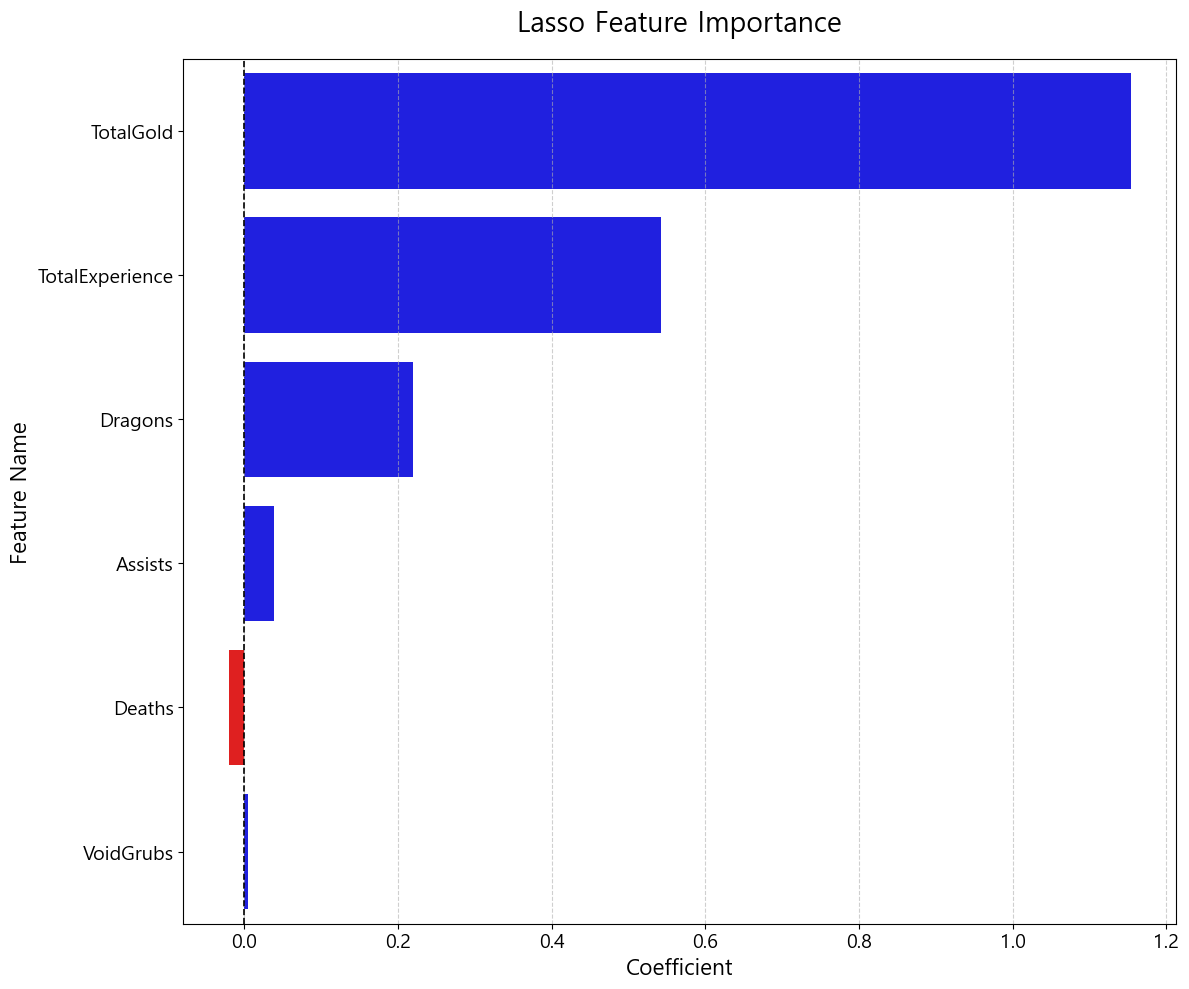


✅ 변수 중요도 분석 완료. 그래프를 확인하세요.
   - 파란색 막대: 해당 변수 값이 클수록 '승리(Positive)' 확률 증가
   - 빨간색 막대: 해당 변수 값이 클수록 '패배(Negative)' 확률 증가
   - 막대가 없는 변수: 모델이 예측에 불필요하다고 판단하여 버린 변수


In [ ]:

selected_features = coef_df[coef_df['Coefficient'] != 0].sort_values(by='Abs_Coefficient', ascending=False)

# 그래프 크기를 조금 더 키워 텍스트가 잘 보이게 조정
plt.figure(figsize=(12, 10))

# 시각화를 위해 색상 구분 (양수는 파랑, 음수는 빨강)
colors = ['blue' if c > 0 else 'red' for c in selected_features['Coefficient']]

sns.barplot(x='Coefficient', y='Feature', data=selected_features, palette=colors)

# [수정] 제목 및 축 레이블 폰트 크기 확대, X축 텍스트 단순화
plt.title('Lasso Feature Importance', fontsize=20, pad=20)  # 제목 추가 및 폰트 키움
plt.xlabel('Coefficient', fontsize=16)                      # X축: 단순하게 'Coefficient'로 변경
plt.ylabel('Feature Name', fontsize=16)                     # Y축: 폰트 키움

# [수정] 눈금(Tick) 폰트 크기 확대
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# 0 기준선 및 그리드 추가 (가독성 향상)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.2)
plt.grid(True, axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("\n✅ 변수 중요도 분석 완료. 그래프를 확인하세요.")
print("   - 파란색 막대: 해당 변수 값이 클수록 '승리(Positive)' 확률 증가")
print("   - 빨간색 막대: 해당 변수 값이 클수록 '패배(Negative)' 확률 증가")
print("   - 막대가 없는 변수: 모델이 예측에 불필요하다고 판단하여 버린 변수")

Lasso가 선택한 변수명: ['TotalGold', 'TotalExperience', 'Dragons', 'Assists', 'Deaths']
매핑 확인: TotalGold -> Diff_TotalGold
매핑 확인: TotalExperience -> Diff_TotalExperience
매핑 확인: Dragons -> Diff_Dragons
매핑 확인: Assists -> Diff_Assists
매핑 확인: Deaths -> Diff_Deaths
원본 데이터에서 사용할 실제 컬럼명: ['Diff_TotalGold', 'Diff_TotalExperience', 'Diff_Dragons', 'Diff_Assists', 'Diff_Deaths']


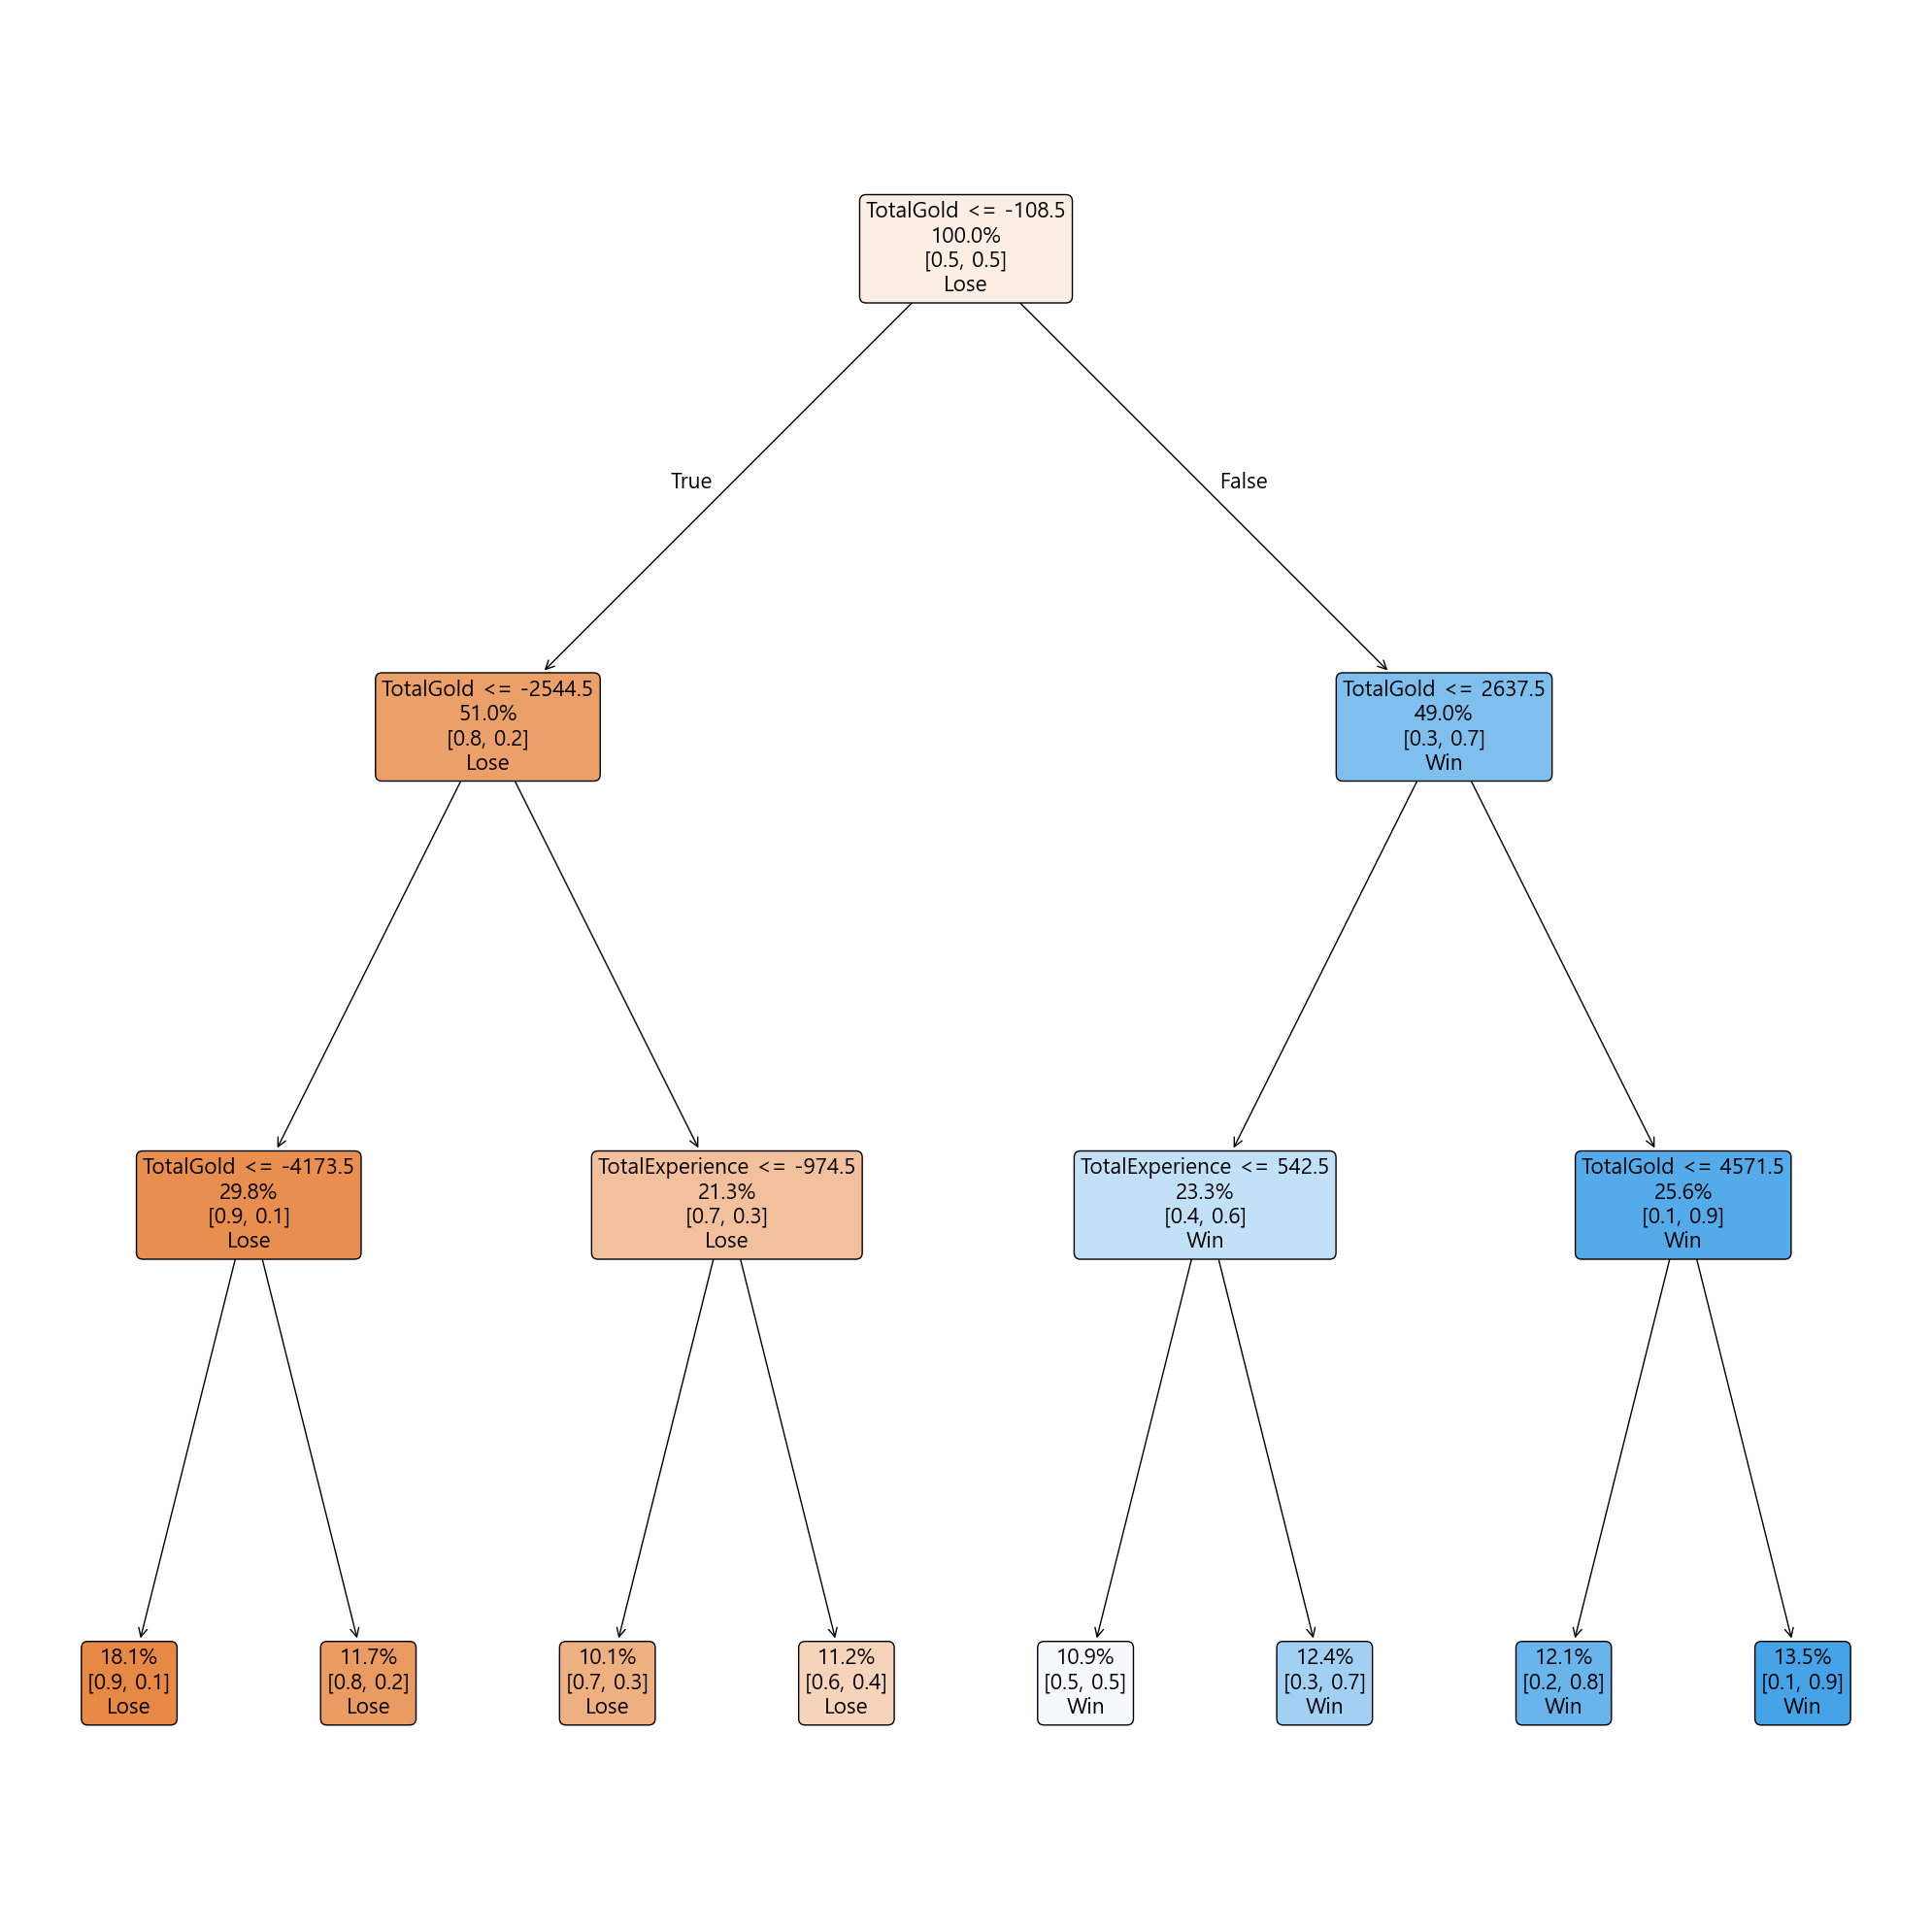


Accuracy: 0.7775
F1-Score: 0.7670


In [68]:
# ======================================================
# [Step 10] 의사결정트리 시각화 (컬럼명 불일치 해결 버전)
# ======================================================
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score

# 1. Lasso 모델에서 상위 5개 중요 변수 추출 (깔끔한 이름)
if 'selected_features' in locals():
    lasso_top5_clean_names = selected_features['Feature'].head(5).tolist()
else:
    # 안전장치
    lasso_top5_clean_names = ['TotalGold', 'TotalExperience', 'Dragons', 'Assists', 'Deaths']

print(f"Lasso가 선택한 변수명: {lasso_top5_clean_names}")

# ------------------------------------------------------
# [중요 수정] X_train_orig에 있는 실제 컬럼명 찾기 ('Diff_' 처리)
# ------------------------------------------------------
actual_columns = []
for name in lasso_top5_clean_names:
    if name in X_train_orig.columns:
        actual_columns.append(name)
    elif f"Diff_{name}" in X_train_orig.columns:
        print(f"매핑 확인: {name} -> Diff_{name}")
        actual_columns.append(f"Diff_{name}")
    else:
        # 혹시 모를 경우를 대비해 가장 유사한 컬럼 찾기
        import difflib
        similar = difflib.get_close_matches(name, X_train_orig.columns, n=1)
        if similar:
            print(f"유사 매핑: {name} -> {similar[0]}")
            actual_columns.append(similar[0])
        else:
            print(f"⚠️ 경고: '{name}' 컬럼을 원본 데이터에서 찾을 수 없습니다.")

print(f"원본 데이터에서 사용할 실제 컬럼명: {actual_columns}")

# ------------------------------------------------------
# 2. 시각화용 트리 모델 학습
# ------------------------------------------------------
dt_viz = DecisionTreeClassifier(max_depth=3, random_state=42)

# 실제 존재하는 컬럼명으로 데이터 추출
X_train_lasso = X_train_orig[actual_columns]
dt_viz.fit(X_train_lasso, y_train)

# ------------------------------------------------------
# 3. 트리 시각화
# ------------------------------------------------------
plt.figure(figsize=(20, 20))

plot_tree(dt_viz,
          # 시각화할 때는 보기 좋게 다시 깔끔한 이름(lasso_top5_clean_names) 사용
          feature_names=lasso_top5_clean_names, 
          class_names=['Lose', 'Win'],
          filled=True,
          rounded=True,
          fontsize=16,
          proportion=True,
          precision=1,
          impurity=False,
          label='none')

plt.tight_layout()
plt.show()

# ------------------------------------------------------
# 4. 성능 평가
# ------------------------------------------------------
X_test_lasso = X_test_orig[actual_columns] # 테스트 데이터도 실제 컬럼명 사용
y_pred_viz = dt_viz.predict(X_test_lasso)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred_viz):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_viz):.4f}")

In [70]:
# ======================================================
# [추가] 의사결정트리 규칙 텍스트로 추출
# ======================================================
from sklearn.tree import export_text

# 직전에 학습된 dt_viz 모델과 깔끔한 변수명 사용
tree_rules = export_text(dt_viz, feature_names=lasso_top5_clean_names)

print("=" * 60)
print("[의사결정트리 규칙 (텍스트 버전)]")
print("=" * 60)
print("읽는 법:")
print("  |--- 조건 : 이 조건이 '참(True)'인 경우 아래로 내려감")
print("  |   |--- class: X : 최종 예측 결과 (0: 패배, 1: 승리)")
print("-" * 60)
print(tree_rules)
print("=" * 60)

[의사결정트리 규칙 (텍스트 버전)]
읽는 법:
  |--- 조건 : 이 조건이 '참(True)'인 경우 아래로 내려감
  |   |--- class: X : 최종 예측 결과 (0: 패배, 1: 승리)
------------------------------------------------------------
|--- TotalGold <= -108.50
|   |--- TotalGold <= -2544.50
|   |   |--- TotalGold <= -4173.50
|   |   |   |--- class: 0
|   |   |--- TotalGold >  -4173.50
|   |   |   |--- class: 0
|   |--- TotalGold >  -2544.50
|   |   |--- TotalExperience <= -974.50
|   |   |   |--- class: 0
|   |   |--- TotalExperience >  -974.50
|   |   |   |--- class: 0
|--- TotalGold >  -108.50
|   |--- TotalGold <= 2637.50
|   |   |--- TotalExperience <= 542.50
|   |   |   |--- class: 1
|   |   |--- TotalExperience >  542.50
|   |   |   |--- class: 1
|   |--- TotalGold >  2637.50
|   |   |--- TotalGold <= 4571.50
|   |   |   |--- class: 1
|   |   |--- TotalGold >  4571.50
|   |   |   |--- class: 1



In [31]:
# ======================================================
# [Real Match Data] 실제 경기 11개 검증 데이터
# ======================================================

my_matches = [
    {"Match": "Match 01", "blueWins": 1, "Diff_TotalGold": 9500, "Diff_TotalExperience": 7200, "Diff_Kills": 18, "Diff_Deaths": -18, "Diff_Assists": 25, "Diff_WardsPlaced": 8, "Diff_ControlWardsPlaced": 4, "Diff_WardsDestroyed": 5, "Diff_Dragons": 3, "Diff_Heralds": 2, "Diff_VoidGrubs": 4, "Diff_TowersDestroyed": 5, "Diff_PlatesDestroyed": 7, "Diff_TotalMinionsKilled": 55, "Diff_TotalJungleMinionsKilled": 22, "Diff_InhibitorsDestroyed": 1, "Diff_FirstTowerDestroyed": 1, "Diff_FirstDragon": 1, "Diff_FirstBlood": 1},
    {"Match": "Match 02", "blueWins": 0, "Diff_TotalGold": -8200, "Diff_TotalExperience": -6500, "Diff_Kills": -16, "Diff_Deaths": 16, "Diff_Assists": -12, "Diff_WardsPlaced": -6, "Diff_ControlWardsPlaced": -4, "Diff_WardsDestroyed": -3, "Diff_Dragons": -2, "Diff_Heralds": -1, "Diff_VoidGrubs": -3, "Diff_TowersDestroyed": -4, "Diff_PlatesDestroyed": -5, "Diff_TotalMinionsKilled": -45, "Diff_TotalJungleMinionsKilled": -18, "Diff_InhibitorsDestroyed": 0, "Diff_FirstTowerDestroyed": 0, "Diff_FirstDragon": 0, "Diff_FirstBlood": 0},
    {"Match": "Match 03", "blueWins": 0, "Diff_TotalGold": -1200, "Diff_TotalExperience": -800, "Diff_Kills": -2, "Diff_Deaths": 2, "Diff_Assists": -5, "Diff_WardsPlaced": 3, "Diff_ControlWardsPlaced": 1, "Diff_WardsDestroyed": 2, "Diff_Dragons": 0, "Diff_Heralds": 0, "Diff_VoidGrubs": -1, "Diff_TowersDestroyed": -1, "Diff_PlatesDestroyed": -1, "Diff_TotalMinionsKilled": -5, "Diff_TotalJungleMinionsKilled": -2, "Diff_InhibitorsDestroyed": 0, "Diff_FirstTowerDestroyed": 0, "Diff_FirstDragon": 1, "Diff_FirstBlood": 0},
    {"Match": "Match 04", "blueWins": 1, "Diff_TotalGold": -3100, "Diff_TotalExperience": -2100, "Diff_Kills": -6, "Diff_Deaths": 6, "Diff_Assists": -9, "Diff_WardsPlaced": -2, "Diff_ControlWardsPlaced": -1, "Diff_WardsDestroyed": -1, "Diff_Dragons": 1, "Diff_Heralds": 0, "Diff_VoidGrubs": 0, "Diff_TowersDestroyed": -1, "Diff_PlatesDestroyed": -2, "Diff_TotalMinionsKilled": -20, "Diff_TotalJungleMinionsKilled": -5, "Diff_InhibitorsDestroyed": 0, "Diff_FirstTowerDestroyed": 0, "Diff_FirstDragon": 0, "Diff_FirstBlood": 0},
    {"Match": "Match 05", "blueWins": 1, "Diff_TotalGold": 1300, "Diff_TotalExperience": 900, "Diff_Kills": 4, "Diff_Deaths": -4, "Diff_Assists": 6, "Diff_WardsPlaced": 1, "Diff_ControlWardsPlaced": 1, "Diff_WardsDestroyed": 0, "Diff_Dragons": 1, "Diff_Heralds": 0, "Diff_VoidGrubs": 1, "Diff_TowersDestroyed": 1, "Diff_PlatesDestroyed": 1, "Diff_TotalMinionsKilled": 12, "Diff_TotalJungleMinionsKilled": 2, "Diff_InhibitorsDestroyed": 0, "Diff_FirstTowerDestroyed": 0, "Diff_FirstDragon": 0, "Diff_FirstBlood": 1},
    {"Match": "Match 06", "blueWins": 0, "Diff_TotalGold": -5200, "Diff_TotalExperience": -4100, "Diff_Kills": -11, "Diff_Deaths": 11, "Diff_Assists": -9, "Diff_WardsPlaced": -5, "Diff_ControlWardsPlaced": -2, "Diff_WardsDestroyed": -2, "Diff_Dragons": -3, "Diff_Heralds": -1, "Diff_VoidGrubs": -2, "Diff_TowersDestroyed": -3, "Diff_PlatesDestroyed": -4, "Diff_TotalMinionsKilled": -12, "Diff_TotalJungleMinionsKilled": -28, "Diff_InhibitorsDestroyed": 0, "Diff_FirstTowerDestroyed": 0, "Diff_FirstDragon": 0, "Diff_FirstBlood": 0},
    {"Match": "Match 07", "blueWins": 1, "Diff_TotalGold": -150, "Diff_TotalExperience": 80, "Diff_Kills": 1, "Diff_Deaths": -1, "Diff_Assists": 1, "Diff_WardsPlaced": 2, "Diff_ControlWardsPlaced": 0, "Diff_WardsDestroyed": 1, "Diff_Dragons": 0, "Diff_Heralds": 0, "Diff_VoidGrubs": 0, "Diff_TowersDestroyed": 0, "Diff_PlatesDestroyed": 0, "Diff_TotalMinionsKilled": 6, "Diff_TotalJungleMinionsKilled": -3, "Diff_InhibitorsDestroyed": 0, "Diff_FirstTowerDestroyed": 1, "Diff_FirstDragon": 0, "Diff_FirstBlood": 1},
    {"Match": "Match 08", "blueWins": 0, "Diff_TotalGold": -2100, "Diff_TotalExperience": -1600, "Diff_Kills": 5, "Diff_Deaths": -5, "Diff_Assists": 2, "Diff_WardsPlaced": -4, "Diff_ControlWardsPlaced": -1, "Diff_WardsDestroyed": -1, "Diff_Dragons": -1, "Diff_Heralds": 0, "Diff_VoidGrubs": -1, "Diff_TowersDestroyed": -4, "Diff_PlatesDestroyed": -2, "Diff_TotalMinionsKilled": -22, "Diff_TotalJungleMinionsKilled": -6, "Diff_InhibitorsDestroyed": 0, "Diff_FirstTowerDestroyed": 0, "Diff_FirstDragon": 1, "Diff_FirstBlood": 0},
    {"Match": "Match 09", "blueWins": 1, "Diff_TotalGold": 4600, "Diff_TotalExperience": 4100, "Diff_Kills": 9, "Diff_Deaths": -9, "Diff_Assists": 7, "Diff_WardsPlaced": 4, "Diff_ControlWardsPlaced": 3, "Diff_WardsDestroyed": 2, "Diff_Dragons": 1, "Diff_Heralds": 1, "Diff_VoidGrubs": 3, "Diff_TowersDestroyed": 4, "Diff_PlatesDestroyed": 5, "Diff_TotalMinionsKilled": 42, "Diff_TotalJungleMinionsKilled": 11, "Diff_InhibitorsDestroyed": 0, "Diff_FirstTowerDestroyed": 1, "Diff_FirstDragon": 1, "Diff_FirstBlood": 1},
    {"Match": "Match 10", "blueWins": 0, "Diff_TotalGold": -7200, "Diff_TotalExperience": -5600, "Diff_Kills": -13, "Diff_Deaths": 13, "Diff_Assists": -16, "Diff_WardsPlaced": -7, "Diff_ControlWardsPlaced": -3, "Diff_WardsDestroyed": -4, "Diff_Dragons": -2, "Diff_Heralds": -1, "Diff_VoidGrubs": -3, "Diff_TowersDestroyed": -5, "Diff_PlatesDestroyed": -6, "Diff_TotalMinionsKilled": -38, "Diff_TotalJungleMinionsKilled": -12, "Diff_InhibitorsDestroyed": 0, "Diff_FirstTowerDestroyed": 0, "Diff_FirstDragon": 0, "Diff_FirstBlood": 0},
    {"Match": "Match 11", "blueWins": 1, "Diff_TotalGold": 2610, "Diff_TotalExperience": -2726, "Diff_Kills": -3, "Diff_Deaths": 3, "Diff_Assists": -5, "Diff_WardsPlaced": -2, "Diff_ControlWardsPlaced": 0, "Diff_WardsDestroyed": 0, "Diff_Dragons": -1, "Diff_Heralds": 0, "Diff_VoidGrubs": 1, "Diff_TowersDestroyed": -1, "Diff_PlatesDestroyed": 0, "Diff_TotalMinionsKilled": 35, "Diff_TotalJungleMinionsKilled": 10, "Diff_InhibitorsDestroyed": 0, "Diff_FirstTowerDestroyed": 0, "Diff_FirstDragon": 0, "Diff_FirstBlood": 1}
]

print("=" * 60)
print("실제 경기 검증 데이터 로드 완료")
print("=" * 60)
print(f"총 경기 수: {len(my_matches)}개")
print(f"블루팀 승리: {sum(m['blueWins'] for m in my_matches)}개")
print(f"블루팀 패배: {len(my_matches) - sum(m['blueWins'] for m in my_matches)}개")
print("=" * 60)

실제 경기 검증 데이터 로드 완료
총 경기 수: 11개
블루팀 승리: 6개
블루팀 패배: 5개


실전 검증: 모델 비교 및 AI 판정 (최종 모델: Lasso)
⚠️ 경고: 다음 컬럼이 데이터에 없어 0으로 대체합니다: {'Diff_ControlWardsDestroyed'}

실전 검증 결과표 (Lasso AI 판정 및 의사결정 근거 추가)
      경기 실제 결과 Lasso 승률 DecisionTree 승률                          Lasso AI 판정                                                       나의 의사결정 근거(Top5)
Match 01   WIN   98.94%          93.90%                        승리요인: Gold 우세 Gold(+9500), Experience(+7200), Dragons(+3), Assists(+25), Deaths(-18)
Match 02  LOSE    2.20%           5.52%                        패배요인: Gold 열세 Gold(-8200), Experience(-6500), Dragons(-2), Assists(-12), Deaths(+16)
Match 03  LOSE   38.34%          39.67%      승리요인: Dragons 우세, 패배요인: Gold 열세    Gold(-1200), Experience(-800), Dragons(+0), Assists(-5), Deaths(+2)
Match 04   WIN   25.44%          16.89%      승리요인: Dragons 우세, 패배요인: Gold 열세   Gold(-3100), Experience(-2100), Dragons(+1), Assists(-9), Deaths(+6)
Match 05   WIN   67.64%          65.59%    승리요인: Gold 우세, 패배요인: VoidGrubs 열세    Gold(+1300), Experience(+900), Dragons(+1)

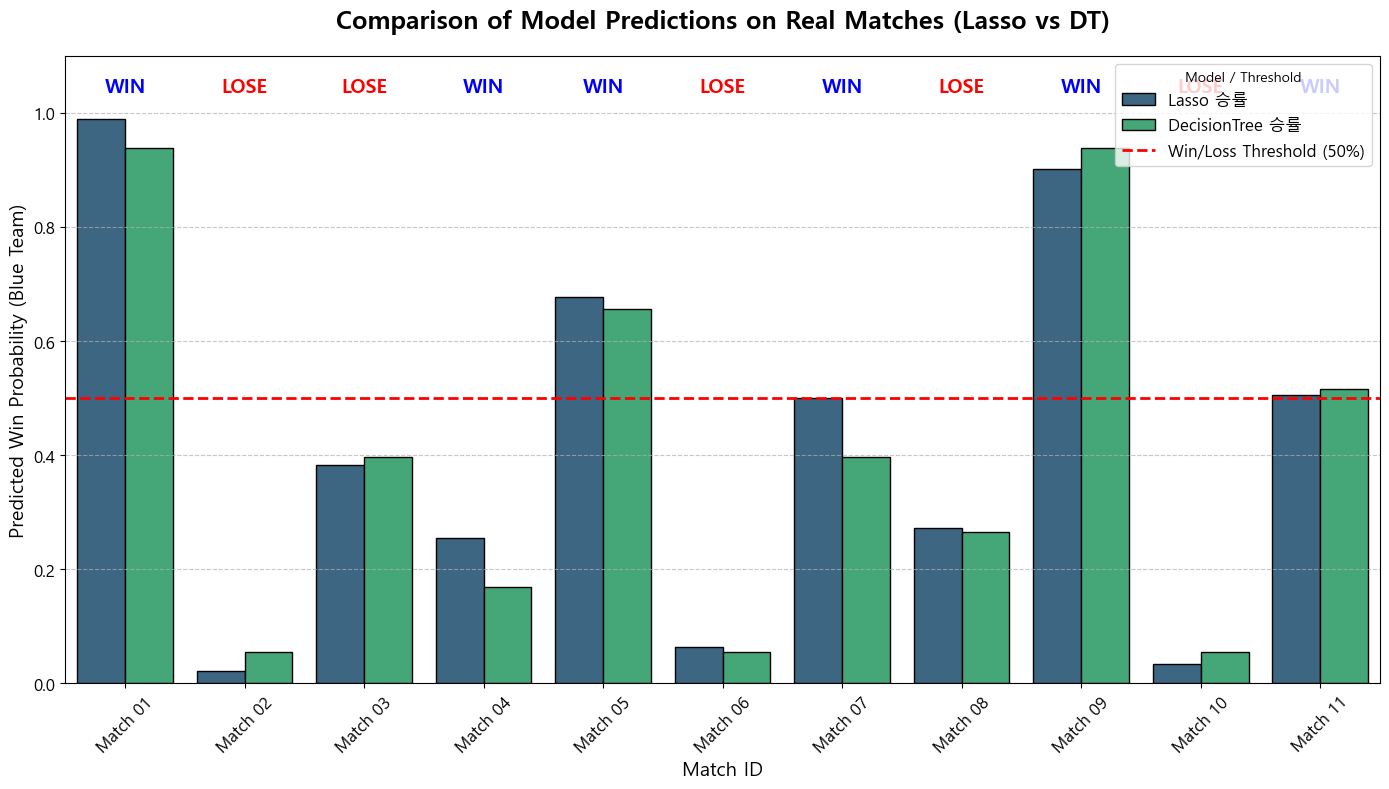

In [53]:
# ======================================================
# [Step 11] 실전 검증 - Lasso 모델 vs 의사결정트리 + AI 판정
# ======================================================
print("=" * 60)
print("실전 검증: 모델 비교 및 AI 판정 (최종 모델: Lasso)")
print("=" * 60)

# 1. 데이터 준비
df_real_matches = pd.DataFrame(my_matches)

# [🚨 핵심 수정] 학습 데이터(X_original)에는 있었으나 현재 없는 컬럼을 0으로 채움
missing_cols = set(X_original.columns) - set(df_real_matches.columns)
if missing_cols:
    print(f"⚠️ 경고: 다음 컬럼이 데이터에 없어 0으로 대체합니다: {missing_cols}")
    for c in missing_cols:
        df_real_matches[c] = 0

# 학습 데이터와 동일한 특성 순서 보장
X_real = df_real_matches[X_original.columns]
y_true = [m['blueWins'] for m in my_matches]

# 2. Lasso 모델 (Scaled 데이터 사용) 예측 및 AI 판정 준비
best_model_name = 'Lasso (Scaled)'
best_model = models_lasso['Scaled'] # 이미 학습된 Scaled Lasso 모델 사용

# 실제 데이터 스케일링 (Lasso 예측 및 계수 분석용)
X_real_scaled = pd.DataFrame(scaler.transform(X_real), columns=X_real.columns)

# Lasso 예측
y_pred_lasso = best_model.predict(X_real_scaled)
y_proba_lasso = best_model.predict_proba(X_real_scaled)[:, 1]

# Lasso 계수 가져오기 (AI 판정용)
lasso_coefs = best_model.coef_[0]
feature_names = X_real.columns

# 3. 의사결정트리 예측 준비
# [✅ 변수명 수정 완료] actual_columns 사용 (모델명도 dt_viz로 통일)
X_real_top5 = X_real[actual_columns]
y_pred_dt = dt_viz.predict(X_real_top5)
y_proba_dt = dt_viz.predict_proba(X_real_top5)[:, 1]

# 4. 결과 종합 및 판정 컬럼 생성
comparison_results = []

for i, match in enumerate(my_matches):
    # --- Lasso AI 판정 로직 ---
    # 각 특성의 기여도 계산 (계수 * 스케일된 값)
    contributions = lasso_coefs * X_real_scaled.iloc[i].values

    # 기여도가 가장 큰 양수(승리 요인)와 음수(패배 요인) 인덱스 찾기
    # 모든 기여도가 0인 경우를 대비해 예외 처리
    if np.all(contributions == 0):
        ai_judgment = "판단 불가 (모든 요인 중립)"
    else:
        max_pos_idx = np.argmax(contributions)
        max_neg_idx = np.argmin(contributions)

        ai_judgment = []
        # 가장 큰 긍정적 요인이 실제로 양수일 때만 추가 (부동소수점 오차 고려)
        if contributions[max_pos_idx] > 0.00001:
            feature_name = feature_names[max_pos_idx].replace('Diff_', '').replace('Total', '')
            ai_judgment.append(f"승리요인: {feature_name} 우세")

        # 가장 작은 부정적 요인이 실제로 음수일 때만 추가
        if contributions[max_neg_idx] < -0.00001:
            feature_name = feature_names[max_neg_idx].replace('Diff_', '').replace('Total', '')
            ai_judgment.append(f"패배요인: {feature_name} 열세")

        ai_judgment = ", ".join(ai_judgment) if ai_judgment else "특이사항 없음 (주요 요인 영향력 미미)"


    # --- 나의 의사결정 근거 (Top5 변수 실제값) ---
    my_decision_factors = []
    # [✅ 여기를 수정했습니다!] top5_features -> actual_columns로 변경
    for feature in actual_columns:
        # my_matches에는 없는 키값이 있을 수 있으므로 안전하게 가져오기 (없으면 0)
        val = match.get(feature, 0)

        # 보기 좋게 포맷팅 (정수는 부호 표시, 실수는 소수점 1자리)
        formatted_val = f"{val:+}" if isinstance(val, int) else f"{val:+.1f}"
        short_feature_name = feature.replace('Diff_', '').replace('Total', '')
        my_decision_factors.append(f"{short_feature_name}({formatted_val})")
    my_decision_str = ", ".join(my_decision_factors)


    comparison_results.append({
        '경기': match['Match'],
        '실제 결과': 'WIN' if match['blueWins'] == 1 else 'LOSE',
        'Lasso 승률': y_proba_lasso[i], # 수치로 저장 (시각화용)
        'DecisionTree 승률': y_proba_dt[i],   # 수치로 저장 (시각화용)
        'Lasso AI 판정': ai_judgment,
        '나의 의사결정 근거(Top5)': my_decision_str
    })

comparison_df = pd.DataFrame(comparison_results)

# 5. 결과 출력 (승률을 % 문자열로 변환하여 표시)
comparison_df_print = comparison_df.copy()
comparison_df_print['Lasso 승률'] = comparison_df_print['Lasso 승률'].apply(lambda x: f"{x*100:.2f}%")
comparison_df_print['DecisionTree 승률'] = comparison_df_print['DecisionTree 승률'].apply(lambda x: f"{x*100:.2f}%")

print("\n" + "=" * 100)
print("실전 검증 결과표 (Lasso AI 판정 및 의사결정 근거 추가)")
print("=" * 100)
# 긴 텍스트가 잘리지 않도록 설정
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000) # 전체 출력 폭 넓게 설정
print(comparison_df_print.to_string(index=False))

# 6. 정확도 계산 및 출력
lasso_accuracy = accuracy_score(y_true, y_pred_lasso)
dt_accuracy = accuracy_score(y_true, y_pred_dt)

print("\n" + "=" * 60)
print(f"✅ Lasso 모델 정확도: {lasso_accuracy:.2%} ({sum(y_pred_lasso == y_true)}/{len(y_true)} 정답)")
print(f"✅ DecisionTree 정확도: {dt_accuracy:.2%} ({sum(y_pred_dt == y_true)}/{len(y_true)} 정답)")
print("=" * 60)

# ======================================================
# [Step 12] 실전 검증 결과 시각화 (막대 그래프)
# ======================================================

# 시각화를 위한 데이터 변환 (Melt)
viz_df = comparison_df.melt(
    id_vars=['경기', '실제 결과'],
    value_vars=['Lasso 승률', 'DecisionTree 승률'],
    var_name='Model',
    value_name='Win Probability'
)

plt.figure(figsize=(14, 8))

# 막대 그래프 그리기
sns.barplot(
    data=viz_df,
    x='경기',
    y='Win Probability',
    hue='Model',
    palette='viridis', # 색상 테마 설정
    edgecolor='black'  # 막대 테두리 추가
)

# 50% 기준선 추가 (승/패 경계)
plt.axhline(0.5, color='red', linestyle='--', linewidth=2, label='Win/Loss Threshold (50%)')

# 그래프 꾸미기
plt.title('Comparison of Model Predictions on Real Matches (Lasso vs DT)', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('Predicted Win Probability (Blue Team)', fontsize=14)
plt.xlabel('Match ID', fontsize=14)
plt.ylim(0, 1.1) # y축 범위 설정 (텍스트 공간 확보를 위해 1.1까지)
plt.legend(title='Model / Threshold', loc='upper right', frameon=True, fontsize=12)
plt.xticks(rotation=45, fontsize=12) # x축 레이블 회전
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 막대 위에 실제 결과 텍스트 추가
# 각 경기별로 루프를 돌며 실제 결과에 따라 WIN(파랑)/LOSE(빨강) 텍스트를 표시합니다.
matches = comparison_df['경기'].unique()
for i, match_name in enumerate(matches):
    actual_result = comparison_df[comparison_df['경기'] == match_name]['실제 결과'].values[0]
    result_text = "WIN" if actual_result == 'WIN' else "LOSE"
    color = 'blue' if actual_result == 'WIN' else 'red'
    # 텍스트 위치 조정 (i: x좌표, 1.03: y좌표)
    plt.text(i, 1.03, result_text, ha='center', va='bottom', color=color, fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

⚠️ 확률이 소수점(0~1)으로 감지되어 퍼센트(0~100)로 자동 변환합니다.


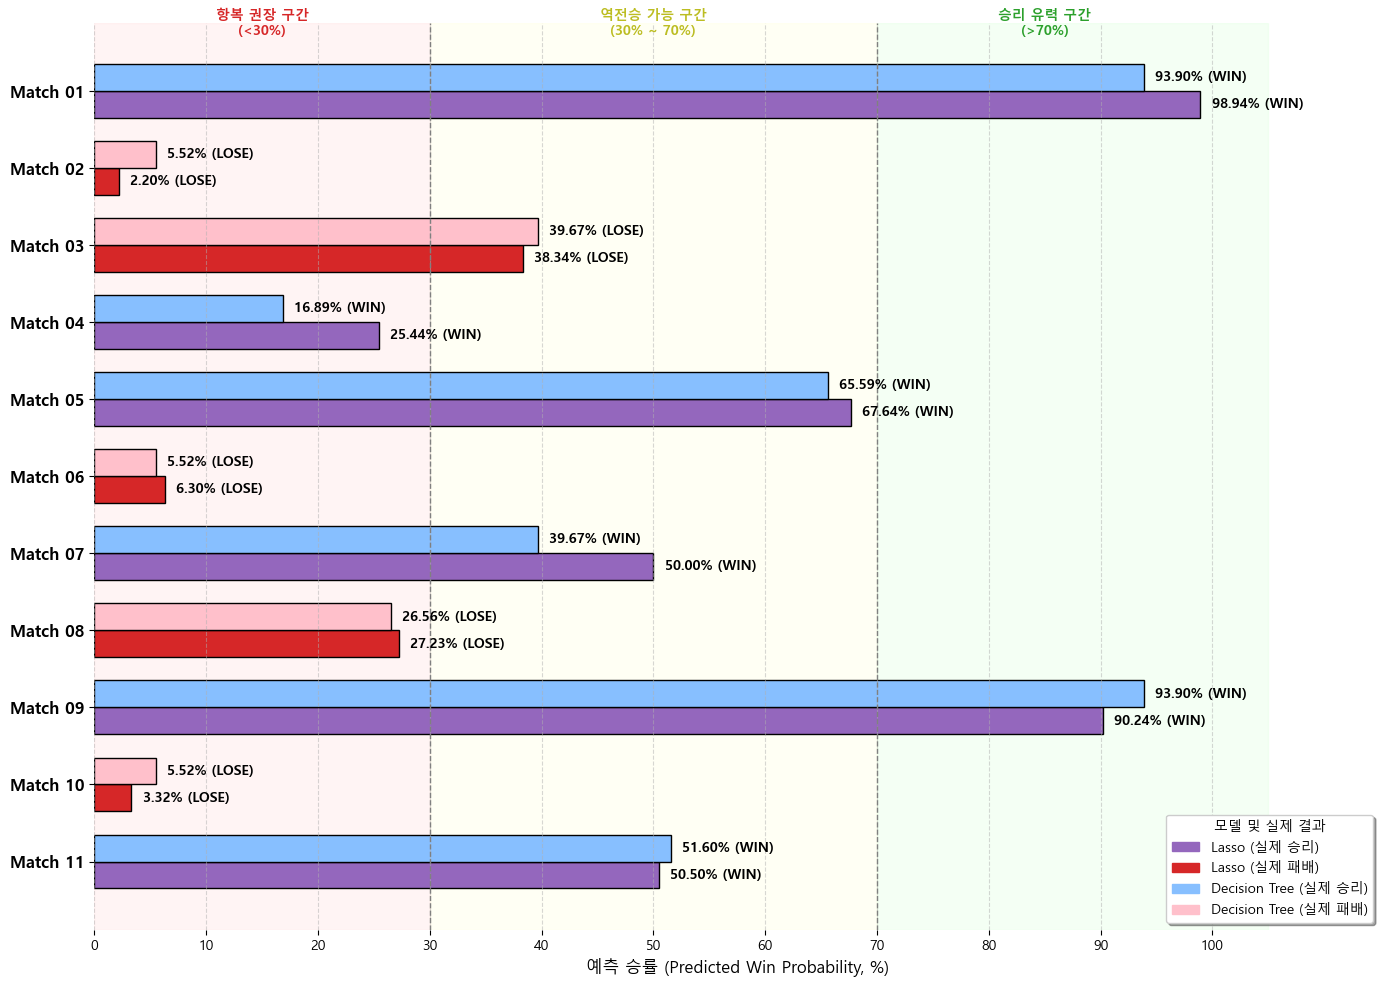

In [69]:
# ======================================================
# [Step 12] 실제 경기 예측 결과 시각화 (단위 오류 수정 버전)
# ======================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.patches as mpatches

# 1. 데이터 준비 (여기가 핵심 수정 파트입니다!)
# ------------------------------------------------------
viz_df = comparison_df.copy()

# [🚨 핵심 수정] 데이터가 소수점(0.06)인지 문자열("6.00%")인지 확인 후 처리
# 샘플로 하나만 찍어서 확인해봅니다.
sample_val = viz_df['Lasso 승률'].iloc[0]

if isinstance(sample_val, str) and '%' in sample_val:
    # 문자열("99.98%")로 되어있는 경우 -> % 떼고 숫자로 변환
    def to_float(x):
        return float(x.strip('%'))
    viz_df['Lasso_Prob'] = viz_df['Lasso 승률'].apply(to_float)
    viz_df['DT_Prob'] = viz_df['DecisionTree 승률'].apply(to_float)
else:
    # 숫자(0.9998)로 되어있는 경우 -> 100을 곱해서 퍼센트로 변환
    # 사용자가 말씀하신 "0.06 이렇게 뜨는" 상황이 바로 여기입니다.
    print("⚠️ 확률이 소수점(0~1)으로 감지되어 퍼센트(0~100)로 자동 변환합니다.")
    viz_df['Lasso_Prob'] = viz_df['Lasso 승률'] * 100
    viz_df['DT_Prob'] = viz_df['DecisionTree 승률'] * 100


# 2. 그래프 설정
# ------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 10))

matches = viz_df['경기'].tolist()
y_pos = np.arange(len(matches))
bar_height = 0.35

# 3. 막대 및 텍스트 그리기 (기존과 동일)
# ------------------------------------------------------
for i, (idx, row) in enumerate(viz_df.iterrows()):
    actual = row['실제 결과']
    lasso_color = '#9467bd' if actual == 'WIN' else '#d62728'
    dt_color = '#87bfff' if actual == 'WIN' else '#ffc0cb'

    # Lasso (위)
    ax.barh(y_pos[i] + bar_height/2, row['Lasso_Prob'], height=bar_height,
            color=lasso_color, edgecolor='black')
    # 텍스트는 이미 퍼센트로 변환된 값을 사용하므로 그대로 출력
    label_text = f"{row['Lasso_Prob']:.2f}% ({actual})"
    ax.text(row['Lasso_Prob'] + 1, y_pos[i] + bar_height/2, label_text,
            va='center', fontweight='bold', fontsize=10)

    # DT (아래)
    ax.barh(y_pos[i] - bar_height/2, row['DT_Prob'], height=bar_height,
            color=dt_color, edgecolor='black')
    label_text = f"{row['DT_Prob']:.2f}% ({actual})"
    ax.text(row['DT_Prob'] + 1, y_pos[i] - bar_height/2, label_text,
            va='center', fontweight='bold', fontsize=10)


# 4. 구간 배경 및 설명 텍스트 (기존과 동일)
# ------------------------------------------------------
ax.axvspan(0, 30, color='#ffdddd', alpha=0.3, zorder=0)
ax.axvspan(30, 70, color='#ffffdd', alpha=0.3, zorder=0)
ax.axvspan(70, 105, color='#ddffdd', alpha=0.3, zorder=0)
ax.axvline(30, color='gray', linestyle='--', linewidth=1)
ax.axvline(70, color='gray', linestyle='--', linewidth=1)

# 5. 그래프 스타일 다듬기 (여백 추가 버전 유지)
# ------------------------------------------------------
ax.set_yticks(y_pos)
ax.set_yticklabels(matches, fontsize=12, fontweight='bold')
# X축 범위를 100보다 조금 더 넓게 잡아서 텍스트가 잘리지 않게 합니다.
ax.set_xlim(0, 115)
ax.set_xticks(range(0, 101, 10))
ax.set_xlabel('예측 승률 (Predicted Win Probability, %)', fontsize=12)

# 막대 위아래 여백 추가 (바닥에 박히는 문제 해결)
ax.margins(y=0.05)

ax.invert_yaxis() # Match 01이 위로 오도록

# 제목 및 그리드
ax.grid(axis='x', linestyle='--', alpha=0.5)
sns.despine(left=True, bottom=True)

# 상단 설명 텍스트 위치 기준점 설정
text_y_pos = ax.get_ylim()[1] + 0.2
ax.text(15, text_y_pos, '항복 권장 구간\n(<30%)', ha='center', va='bottom', fontweight='bold', color='#d62728')
ax.text(50, text_y_pos, '역전승 가능 구간\n(30% ~ 70%)', ha='center', va='bottom', fontweight='bold', color='#bcbd22')
ax.text(85, text_y_pos, '승리 유력 구간\n(>70%)', ha='center', va='bottom', fontweight='bold', color='#2ca02c')

# 범례
legend_patches = [
    mpatches.Patch(color='#9467bd', label='Lasso (실제 승리)'),
    mpatches.Patch(color='#d62728', label='Lasso (실제 패배)'),
    mpatches.Patch(color='#87bfff', label='Decision Tree (실제 승리)'),
    mpatches.Patch(color='#ffc0cb', label='Decision Tree (실제 패배)'),
]
ax.legend(handles=legend_patches, loc='lower right', title='모델 및 실제 결과', frameon=True, shadow=True)

plt.subplots_adjust(top=0.85)
plt.tight_layout()
plt.show()